# Import Libraries

In [2]:
import json
import numpy as np
import pandas as pd
import base64
import matplotlib.pyplot as plt
import seaborn as sns
import re
from rapidfuzz import process, fuzz

# Data Exploration and Analysis

In [3]:
# Reading data
data = pd.read_csv("data/data.csv",header=None, names=["id", "encoded"])

In [4]:
data.columns

Index(['id', 'encoded'], dtype='str')

In [5]:
# Function to decode each Base64 row
def decode_row(encoded):
    try:
        decoded_bytes = base64.b64decode(encoded)
        decoded_str = decoded_bytes.decode('utf-8')
        return json.loads(decoded_str)
    except Exception as e:
        return None 

In [6]:
# Apply Decoding
data["decoded"] = data["encoded"].apply(decode_row)

In [7]:
# Count Bad rows 
bad_rows = data[data["decoded"].isnull()]
print("Bad rows",len(bad_rows))

Bad rows 1


In [8]:
# convert decoded JSON to a Dataframe of its columns
decoded_df = data["decoded"].dropna().apply(pd.Series)

In [9]:
# combine original id with decoded content
final_df = pd.concat([data["id"],decoded_df],axis=1)
final_df = final_df.dropna(subset=["Asset ID"])

In [10]:
final_df.shape

(88513, 10)

In [11]:
final_df.columns

Index(['id', 'Asset ID', 'MAC Address', 'OS', 'Function', 'Vendor and Model',
       'DHCP Options Fingerprint', 'DHCP Request Fingerprint',
       'DHCP Vendor Class', 'DHCP Device Class'],
      dtype='str')

In [12]:
final_df.head()

,id,Asset ID,MAC Address,OS,Function,Vendor and Model,DHCP Options Fingerprint,DHCP Request Fingerprint,DHCP Vendor Class,DHCP Device Class
1,1,1.0,100000000000,Android 7.0,Computer,Unknown,NaN,NaN,NaN,NaN
2,2,2.0,100020000000,Apple Desktop OS,Workstation,Apple iPhone,"53,55,57,61,50,54,12","1,121,3,6,15,108,114,119,252",NaN,NaN
3,3,3.0,100020000001,Apple Desktop OS,Workstation,Apple,"53,55,57,61,51,12","1,121,3,6,15,108,114,119,252",NaN,NaN
4,4,4.0,100020000002,Apple Desktop OS,Workstation,Apple,"53,55,57,61,51,12","1,121,3,6,15,108,114,119,252",NaN,NaN
5,5,5.0,100020000003,Apple Desktop OS,Workstation,Apple iPhone,"53,55,57,61,51,12","1,121,3,6,15,108,114,119,252",NaN,NaN


In [13]:
duplicate_count = final_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
final_df.isna().sum()

id                              0
Asset ID                        0
MAC Address                     0
OS                          31212
Function                       16
Vendor and Model               16
DHCP Options Fingerprint    26032
DHCP Request Fingerprint    26032
DHCP Vendor Class           39961
DHCP Device Class           49370
dtype: int64

In [15]:
# % missing values 
final_df.isna().mean().round(3) *100

id                           0.0
Asset ID                     0.0
MAC Address                  0.0
OS                          35.3
Function                     0.0
Vendor and Model             0.0
DHCP Options Fingerprint    29.4
DHCP Request Fingerprint    29.4
DHCP Vendor Class           45.1
DHCP Device Class           55.8
dtype: float64

In [16]:
# Uniqueness check

print("Unique Asset IDs",final_df["Asset ID"].nunique())
print("Unique OS ",final_df["OS"].nunique())
print("Unique Function",final_df["Function"].nunique())
print("Unique Vendor and Model",final_df["Vendor and Model"].nunique())
print("Unique DHCP Options Fingerprint",final_df["DHCP Options Fingerprint"].nunique())
print("Unique DHCP Request Fingerprint",final_df["DHCP Request Fingerprint"].nunique())
print("Unique DHCP Vendor Class",final_df["DHCP Vendor Class"].nunique())
print("Unique DHCP Device Class",final_df["DHCP Device Class"].nunique())


Unique Asset IDs 88513
Unique OS  32
Unique Function 83
Unique Vendor and Model 314
Unique DHCP Options Fingerprint 162
Unique DHCP Request Fingerprint 135
Unique DHCP Vendor Class 121
Unique DHCP Device Class 14


In [17]:
# Uniqueness check

print("Unique Asset IDs",final_df["Asset ID"].nunique())
# duplicate Mac addresses
duplicate_macs = final_df[final_df["MAC Address"].duplicated(keep=False)]
print("Duplicated Mac rows",duplicate_macs.shape[0])
# Duplicate Vendor + Model
duplicate_vendor_model = final_df[final_df["Vendor and Model"].duplicated(keep=False)]
print("Duplicated Vendor and Model rows",duplicate_vendor_model.shape[0])

Unique Asset IDs 88513
Duplicated Mac rows 14
Duplicated Vendor and Model rows 88456


In [18]:
final_df["Function"].value_counts().head(20)

Function
IP Phone                  29842
Workstation               18514
Switch                     9282
Computer                   6460
Smartphone                 4075
Printer                    3025
Wireless Access Point      2280
Information Technology     2167
Networking                 1421
Router or Switch           1379
Wireless Controller         842
Unknown                     792
IP Camera                   734
Smartwatch                  713
Out Of Band Controller      587
Mobile                      581
Tablet                      507
Communication System        507
Building Automation         456
Router                      359
Name: count, dtype: int64

In [19]:
(final_df["OS"].value_counts(normalize=True).head(10) * 100).round(2)

OS
Apple Desktop OS        16.68
Linux                   16.10
Embedded Firmware       15.22
Chrome OS               11.59
Cisco IOS 15.1           5.22
Cisco IOS 12.2(53)EY     5.05
Cisco IOS 16.12.3        4.49
Android 7.0              4.04
Apple iOS                3.66
Cisco IOS 16.12.4        3.66
Name: proportion, dtype: float64

In [20]:
(final_df["Function"].value_counts(normalize=True).head(10) * 100).round(2)

Function
IP Phone                  33.72
Workstation               20.92
Switch                    10.49
Computer                   7.30
Smartphone                 4.60
Printer                    3.42
Wireless Access Point      2.58
Information Technology     2.45
Networking                 1.61
Router or Switch           1.56
Name: proportion, dtype: float64

In [21]:
(final_df["Vendor and Model"].value_counts(normalize=True).head(10) * 100).round(2)

Vendor and Model
Cisco IP Phone 7942         14.71
Cisco IP Phone 7962          8.41
Cisco IP Phone               7.67
HP                           7.51
Intel                        7.22
Apple iPhone                 5.39
Apple                        4.36
Cisco Switch 4500 Series     3.38
Cisco Router or Switch       3.27
Cisco Switch 9300 Series     2.90
Name: proportion, dtype: float64

In [22]:
top_functions = final_df["Function"].value_counts().head(10).index
top_os = final_df["OS"].value_counts().head(10).index

filtered_df = final_df[
    final_df["Function"].isin(top_functions) &
    final_df["OS"].isin(top_os)
]

pd.crosstab(filtered_df["Function"], filtered_df["OS"])

OS,Android 7.0,Apple Desktop OS,Apple iOS,Chrome OS,Cisco IOS 12.2(53)EY,Cisco IOS 15.1,Cisco IOS 16.12.3,Cisco IOS 16.12.4,Embedded Firmware,Linux
Function,,,,,,,,,,
Computer,919,874,0,682,0,0,0,0,0,776
IP Phone,0,0,0,0,0,0,0,0,8724,3
Information Technology,0,285,1436,16,0,0,0,0,0,20
Networking,96,7,0,6,0,0,0,0,0,24
Printer,0,0,0,34,0,0,0,0,0,399
Router or Switch,0,0,0,0,1340,0,0,0,0,0
Smartphone,0,3986,0,0,0,0,0,0,0,47
Switch,0,0,0,0,1555,2991,2570,2098,0,0
Wireless Access Point,0,0,0,0,0,0,0,0,0,16


In [23]:
(pd.crosstab(
    filtered_df["Function"],
    filtered_df["OS"],
    normalize="index"
)*100).round(1)

OS,Android 7.0,Apple Desktop OS,Apple iOS,Chrome OS,Cisco IOS 12.2(53)EY,Cisco IOS 15.1,Cisco IOS 16.12.3,Cisco IOS 16.12.4,Embedded Firmware,Linux
Function,,,,,,,,,,
Computer,28.3,26.9,0.0,21.0,0.0,0.0,0.0,0.0,0.0,23.9
IP Phone,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
Information Technology,0.0,16.2,81.7,0.9,0.0,0.0,0.0,0.0,0.0,1.1
Networking,72.2,5.3,0.0,4.5,0.0,0.0,0.0,0.0,0.0,18.0
Printer,0.0,0.0,0.0,7.9,0.0,0.0,0.0,0.0,0.0,92.1
Router or Switch,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0
Smartphone,0.0,98.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.2
Switch,0.0,0.0,0.0,0.0,16.9,32.5,27.9,22.8,0.0,0.0
Wireless Access Point,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


In [24]:
final_df["MAC Address"].str.len().value_counts()

MAC Address
12    88077
8       148
10       82
5        36
11       15
4        13
13       11
14       11
15       11
16       11
17       11
18       11
19       11
3         9
9         9
6         8
7         5
20        4
21        4
22        4
23        3
24        3
25        3
26        3
27        3
28        3
2         2
29        2
Name: count, dtype: int64

In [25]:
final_df["OS"].str.lower().value_counts().head(20)

OS
apple desktop os         9557
linux                    9227
embedded firmware        8724
chrome os                6644
cisco ios 15.1           2991
cisco ios 12.2(53)ey     2895
cisco ios 16.12.3        2570
android 7.0              2317
apple ios                2100
cisco ios 16.12.4        2098
debian                   2011
linux embedded           1842
cisco ios 15.3           1400
android                   600
windows 10 enterprise     395
windows kernel 6.0        309
windows 10                295
windows                   291
cisco ios 12.4            264
vxworks                   264
Name: count, dtype: int64

In [26]:
final_df[[
    "DHCP Options Fingerprint",
    "DHCP Request Fingerprint"
]].isna().mean() * 100

DHCP Options Fingerprint    29.410369
DHCP Request Fingerprint    29.410369
dtype: float64

In [27]:
# Identify Outliers in Categorical EDA

# Rare OS values (<0.1%)
os_counts = final_df["OS"].value_counts(normalize=True)
rare_os = os_counts[os_counts<0.001]
print("Rare OS values",rare_os)

# Rare vendor
vendor_counts = final_df["Vendor and Model"].value_counts(normalize=True)
rare_vendors = vendor_counts[vendor_counts <0.001]
print("Rare vendor values",rare_vendors)

Rare OS values OS
Cisco AireOS 8.3                   0.000820
Windows 10 Enterprise 2016 LTSB    0.000698
Nut OS                             0.000401
APC AOS                            0.000314
VxWorks 6.5                        0.000157
Windows 7 Embedded Standard SP1    0.000070
Cisco IOS 15.2                     0.000052
CentOS 7                           0.000052
Name: proportion, dtype: float64
Rare vendor values Vendor and Model
Cisco IP Phone 8831               0.000915
RaspberryPi                       0.000904
Samsung                           0.000847
Fujitsu Technology                0.000836
Cisco Switch 3750 Series          0.000723
                                    ...   
Apple Airport Express             0.000011
Roku                              0.000011
Cisco TelePresence EX60 System    0.000011
Cisco TelePresence MX Series      0.000011
Siemens Magnetom MRI Scanner      0.000011
Name: proportion, Length: 244, dtype: float64


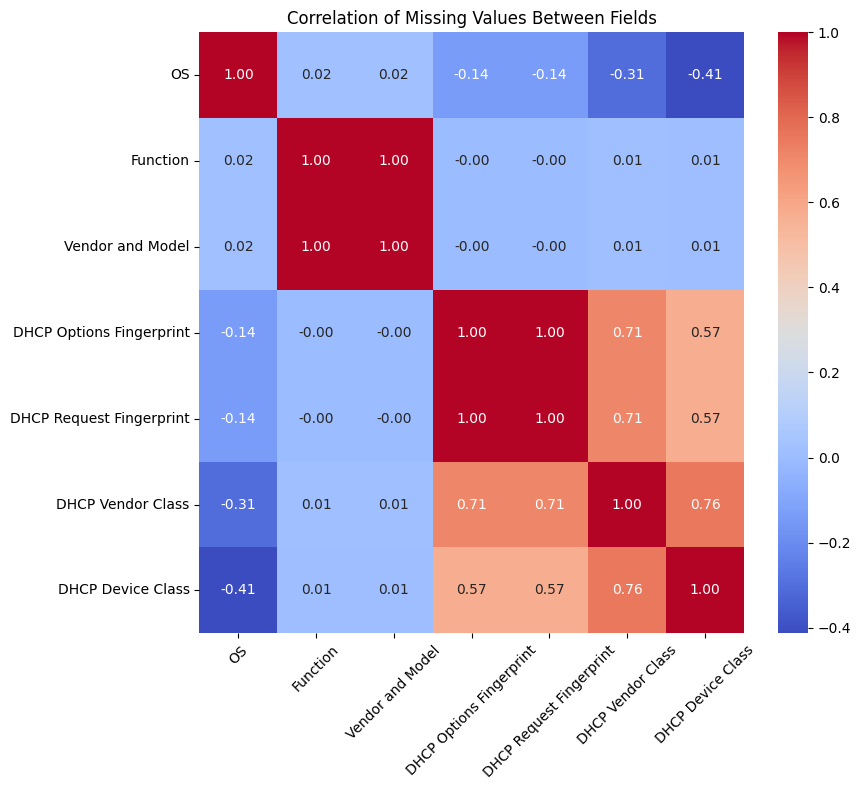

In [28]:
# Correlation of missing values 

missing_df = final_df.isnull().astype(int)

# Remove columns with no missing values
missing_df = missing_df.loc[:, missing_df.sum() > 0]

# Correlation
missing_matrix = missing_df.corr()

plt.figure(figsize=(9, 8))
sns.heatmap(
    missing_matrix,
    cmap="coolwarm",
    annot=True,        
    fmt=".2f",        
)

plt.title("Correlation of Missing Values Between Fields")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# DHCP Fingerprint Length Analysis 

final_df["DHCP_Opt_len"] = (
    final_df["DHCP Options Fingerprint"]
    .fillna("")
    .str.split(",")
    .apply(lambda x: len(x) if x != [''] else 0)
)
final_df["DHCP_Req_len"] = (
    final_df["DHCP Request Fingerprint"]
    .fillna("")
    .str.split(",")
    .apply(lambda x: len(x) if x != [''] else 0)
)
final_df[["DHCP_Opt_len","DHCP_Req_len"]].describe()

,DHCP_Opt_len,DHCP_Req_len
count,88513.000000,88513.000000
mean,3.836849,7.100256
std,2.558567,5.390263
min,0.000000,0.000000
25%,0.000000,0.000000
50%,5.000000,7.000000
75%,5.000000,10.000000
max,14.000000,36.000000


In [30]:
vendor = final_df["Vendor and Model"].fillna("").str.lower()
os_val = final_df["OS"].fillna("").str.lower()

final_df["OS_Vendor_mismatch"] = (
    (vendor.str.contains("apple") & os_val.str.contains("android|windows")) |
    (vendor.str.contains("samsung") & os_val.str.contains("ios")) |
    (vendor.str.contains("cisco") & os_val.str.contains("android|ios")) |
    (vendor.str.contains("iphone|ipad") & os_val.str.contains("windows|android"))
)

In [31]:
f = final_df["Function"].fillna("").str.lower()
vm = final_df["Vendor and Model"].fillna("").str.lower()

final_df["Function_Model_issue"] = (
    ((f.str.contains("workstation")) & (vm.str.contains("iphone|smartphone"))) |
    ((f.str.contains("smartphone")) & (vm.str.contains("iphone|smartphone")))
)

In [32]:
# Summary of Data quality issue 

quality_summary = {
    "Null % per column": final_df.isnull().mean().sort_values(ascending=False) *100,
    "OS-Vendor Mismatches":int(final_df["OS_Vendor_mismatch"].sum()),
    "Function-Model Issues":int(final_df["Function_Model_issue"].sum()),
    "Duplicate MACs":duplicate_macs.shape[0]
}
quality_summary

{'Null % per column': DHCP Device Class           55.777117
 DHCP Vendor Class           45.147041
 OS                          35.262617
 DHCP Request Fingerprint    29.410369
 DHCP Options Fingerprint    29.410369
 Function                     0.018076
 Vendor and Model             0.018076
 MAC Address                  0.000000
 id                           0.000000
 Asset ID                     0.000000
 DHCP_Opt_len                 0.000000
 DHCP_Req_len                 0.000000
 OS_Vendor_mismatch           0.000000
 Function_Model_issue         0.000000
 dtype: float64,
 'OS-Vendor Mismatches': 12392,
 'Function-Model Issues': 4615,
 'Duplicate MACs': 14}

# Additional conclusive information

## Idea 1 - Add Category column

In [33]:
def classify_category(function):
    if not isinstance(function,str):
        return "Unknown"
    f = function.lower()
    if "workstation" in f or "computer" in f or "server" in f:
        return "IT"
    if "switch" in f or "router" in f or "firewall" in f:
        return "Network"
    if "scanner" in f or "ct" in f or "x-ray" in f or "mri" in f:
        return "Medical"
    if "plc" in f or "hmi" in f or "rtu" in f:
        return "OT"
    if "phone" in f or "smart" in f:
        return "IoT"
    return "IoT"

In [34]:
final_df["Category"] = final_df["Function"].apply(classify_category)

In [35]:
final_df.columns

Index(['id', 'Asset ID', 'MAC Address', 'OS', 'Function', 'Vendor and Model',
       'DHCP Options Fingerprint', 'DHCP Request Fingerprint',
       'DHCP Vendor Class', 'DHCP Device Class', 'DHCP_Opt_len',
       'DHCP_Req_len', 'OS_Vendor_mismatch', 'Function_Model_issue',
       'Category'],
      dtype='str')

C:\Users\datas\AppData\Local\Temp\ipykernel_17152\3067440812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


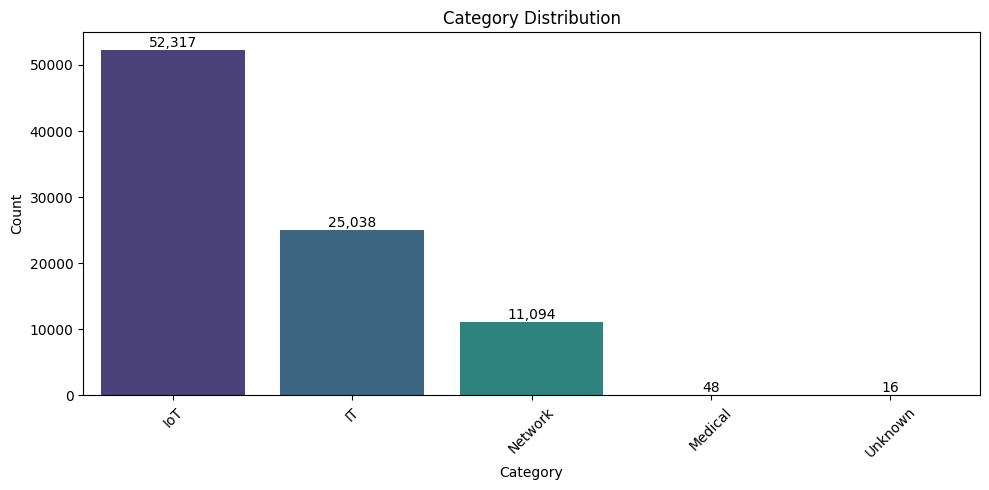

In [497]:
# plotting 

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=final_df,
    x="Category",
    order=final_df["Category"].value_counts().index,
    palette="viridis"   # You can change palette
)

# Rotate x labels if needed
plt.xticks(rotation=45)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(
        format(int(p.get_height()), ','),   # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

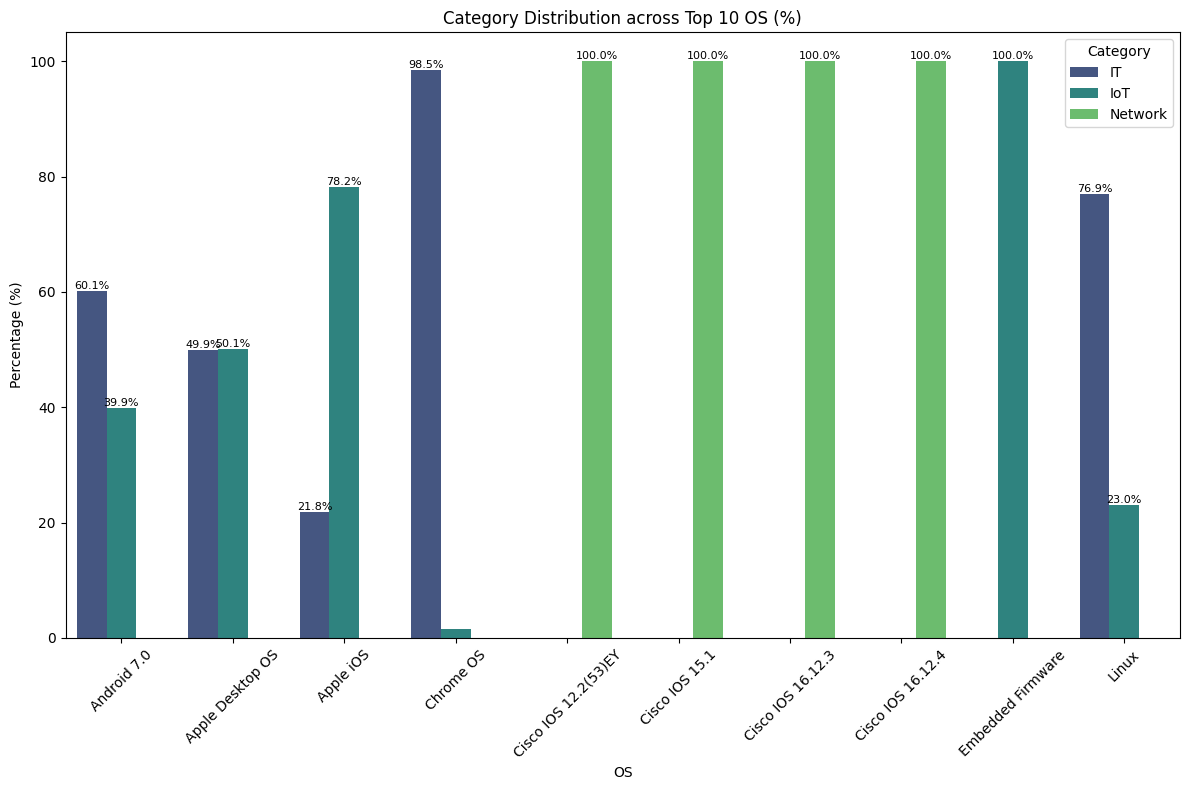

In [498]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Get Top 15 OS
# -----------------------------
top_os = final_df["OS"].value_counts().head(10).index

df_top = final_df[final_df["OS"].isin(top_os)]

# -----------------------------
# 2. Create percentage table
# -----------------------------
ct = pd.crosstab(df_top["OS"], df_top["Category"], normalize="index") * 100
ct = ct.reset_index()

# Convert to long format for seaborn
df_plot = ct.melt(id_vars="OS", var_name="Category", value_name="percentage")

# -----------------------------
# 3. Plot
# -----------------------------
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=df_plot,
    x="OS",
    y="percentage",
    hue="Category",
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Category Distribution across Top 10 OS (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("OS")

# -----------------------------
# 4. Add percentage labels
# -----------------------------
for p in ax.patches:
    height = p.get_height()
    if height > 2:  # avoid clutter
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.legend(title="Category")
plt.tight_layout()
plt.show()

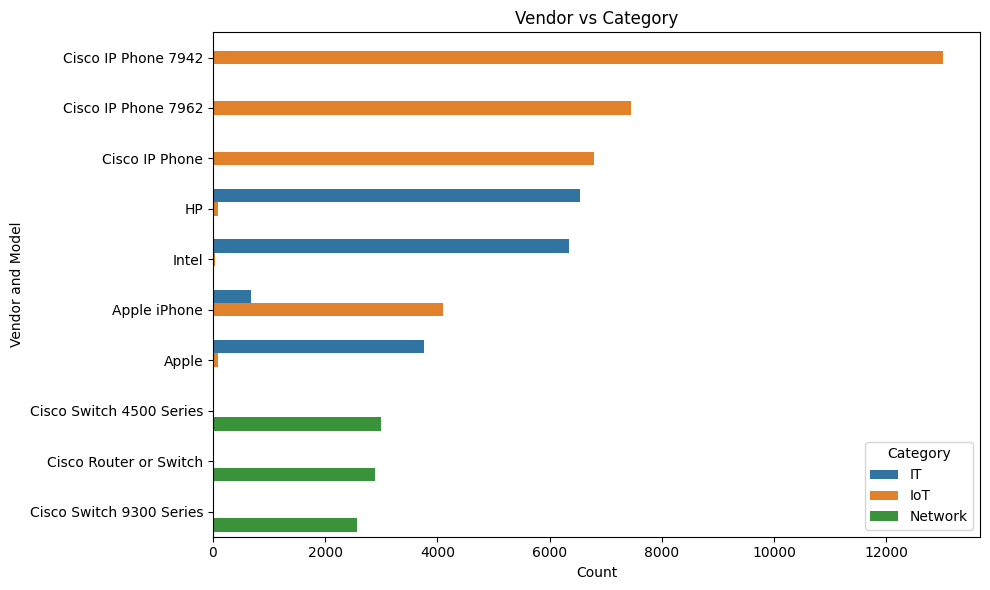

In [499]:
top_functions = final_df["Vendor and Model"].value_counts().head(10).index
filtered_df = final_df[final_df["Vendor and Model"].isin(top_functions)]

plt.figure(figsize=(10,6))

sns.countplot(
    data=filtered_df,
    y="Vendor and Model",   # 👈 switched to Y-axis
    hue="Category",
    order=top_functions
)

plt.title("Vendor vs Category")
plt.xlabel("Count")
plt.ylabel("Vendor and Model")

plt.tight_layout()
plt.show()

## Idea 2 - Vendor and OS Normalized ( Standardized Manufacturing Name)

In [500]:
final_df["Vendor and Model"].unique().tolist()

['Unknown',
 'Apple iPhone',
 'Apple',
 'Apple iPad',
 'Dell',
 'Apple Watch',
 'Multiple',
 'Belkin',
 'Apple iPod',
 'Apple iDevice',
 'Intel',
 'HP',
 'HP Printer',
 'Cisco Router 2900 Series',
 'Cisco Access Point',
 'Cisco',
 'LG',
 'LG TV',
 'Cisco IP Phone 7942',
 'Cisco IP Phone 7962',
 'Siemens',
 'Apple Mac Pro',
 'Texas Instruments',
 'American Power Conversion',
 'Cisco Router or Switch',
 'Cisco IP Phone',
 'Cisco TelePresence SX80 System',
 'Cisco TelePresence MX800ST System',
 'Cisco IP Phone 8821',
 'Cisco TelePresence MX300 G2 System',
 'BrainLab DICOM Proxy',
 'Samsung Galaxy Phone S Series',
 'Samsung',
 'Siemens syngo DICOM System',
 'Lexmark Printer',
 'Cisco Switch 4500 Series',
 'Cisco Switch 3750 Series',
 'Cisco IP Phone 7965',
 'Cisco Router 3900 Series',
 'GE MRI Scanner',
 'Sony',
 'HP Integrated Lights Out',
 'Apple MacBook',
 'Ricoh',
 nan,
 'Cisco IP Phone 8851',
 'Cisco Switch 9300 Series',
 'AzureWave',
 'AAEON Technology',
 'Biamp Systems',
 'Printroni

In [501]:
# -----------------------------
# 1. Canonical vendor list (knowledge base)
# -----------------------------
VENDORS = [
    "Apple", "Dell", "HP", "Cisco", "Siemens", "GE", "IBM", "Microsoft",
    "Samsung", "LG", "Aruba", "Juniper", "Fortinet", "Palo Alto Networks",
    "Lenovo", "Netgear", "Sony", "Philips", "Oracle", "VMware",
    "Roche", "Honeywell", "Panasonic", "Avaya"
]

vendor_lookup = [v.lower() for v in VENDORS]


# -----------------------------
# 2. Text preprocessing
# -----------------------------
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# -----------------------------
# 3. NLP-based vendor extraction
# -----------------------------
def extract_vendor(text):
    text = clean_text(text)
    if not text:
        return "Unknown"

    # Step 1: direct fuzzy match on full string
    match = process.extractOne(text, vendor_lookup, scorer=fuzz.partial_ratio)

    if match and match[1] >= 85:   # threshold can be tuned
        return VENDORS[vendor_lookup.index(match[0])]

    # Step 2: token-level matching (important for cases like "cisco router 2900")
    tokens = text.split()

    best_vendor = "Other"
    best_score = 0

    for vendor in vendor_lookup:
        vendor_tokens = vendor.split()

        score = fuzz.partial_ratio(" ".join(tokens), vendor)

        if score > best_score:
            best_score = score
            best_vendor = vendor

    if best_score >= 80:
        return VENDORS[vendor_lookup.index(best_vendor)]

    return "Other"


# -----------------------------
# 4. Apply to dataset
# -----------------------------
final_df["vendor_normalized"] = final_df["Vendor and Model"].apply(extract_vendor)

In [502]:
final_df["vendor_normalized"].unique().tolist()

['Other',
 'Apple',
 'Dell',
 'HP',
 'Cisco',
 'LG',
 'Siemens',
 'Samsung',
 'GE',
 'Sony',
 'Unknown',
 'Philips',
 'IBM',
 'Oracle',
 'Roche',
 'Aruba',
 'VMware',
 'Microsoft',
 'Honeywell',
 'Netgear',
 'Fortinet',
 'Palo Alto Networks',
 'Juniper',
 'Panasonic',
 'Avaya']

In [503]:
final_df["OS"].unique().tolist()

['Android 7.0',
 'Apple Desktop OS',
 'Debian',
 nan,
 'APC AOS',
 'Apple iOS',
 'Linux',
 'Chrome OS',
 'Cisco IOS 15.0',
 'Cisco IOS 15.3',
 'Cisco IOS 12.4',
 'Windows',
 'Linux Embedded',
 'Cisco IOS 12.2(53)EY',
 'Embedded Firmware',
 'Cisco IOS 15.1',
 'Cisco IOS 12.2(53)SE2',
 'VxWorks 6.5',
 'Cisco IOS 16.12.3',
 'Windows 10',
 'Android',
 'Windows Kernel 6.0',
 'Windows 10 Enterprise',
 'Apple',
 'Cisco IOS 16.12.4',
 'Cisco IOS 15.2',
 'Nut OS',
 'VxWorks',
 'Cisco AireOS 8.3',
 'Windows 7 Embedded Standard SP1',
 'Windows 10 Enterprise 2016 LTSB',
 'CentOS 7',
 'Raspbian']

In [504]:
OS_CATEGORIES = {
    "windows": "Windows",
    "linux": "Linux",
    "debian": "Linux",
    "centos": "Linux",
    "raspbian": "Linux",
    
    "android": "Android",
    "ios": "iOS",
    
    "apple desktop": "macOS",
    "mac": "macOS",
    
    "cisco ios": "Network OS",
    "aireos": "Network OS",
    
    "vxworks": "Embedded/RTOS",
    "nut os": "Embedded/RTOS",
    "embedded": "Embedded/RTOS",
    "apc aos": "Embedded/RTOS",
    
    "chrome os": "Chrome OS"
}


def clean_os(text):
    if pd.isna(text):
        return "Unknown"
    
    return str(text).lower().strip()


def normalize_os(os_value):
    os_value = clean_os(os_value)
    
    if not os_value:
        return "Unknown"

    # Step 1: direct keyword mapping
    for key, label in OS_CATEGORIES.items():
        if key in os_value:
            return label

    # Step 2: fuzzy matching fallback
    keys = list(OS_CATEGORIES.keys())

    match = process.extractOne(os_value, keys, scorer=fuzz.partial_ratio)

    if match and match[1] >= 80:
        return OS_CATEGORIES[match[0]]

    return "Other"


final_df["OS_normalized"] = final_df["OS"].apply(normalize_os)

In [505]:
final_df["OS_normalized"].unique().tolist()

['Android',
 'macOS',
 'Linux',
 'Other',
 'Embedded/RTOS',
 'iOS',
 'Chrome OS',
 'Windows',
 'Network OS']

## Idea 3 - Add a Risk Level column

Rules :
- High -> Outdated OS,Unknown vendor, missing fingerprints
- Medium -> Moderate mising values
- Low -> Clean,complete,modern OS

In [506]:
import pandas as pd
import numpy as np

def risk_level(row):
    
    os_raw = str(row.get("OS", "")).lower()
    vendor = row.get("vendor_normalized", None)

    # -----------------------------
    # 1. Missing fingerprint signals (security visibility gap)
    # -----------------------------
    fp_fields = [
        "DHCP Options Fingerprint",
        "DHCP Request Fingerprint",
        "DHCP Vendor Class",
        "DHCP Device Class"
    ]

    missing_fp = sum(pd.isna(row.get(col)) for col in fp_fields)

    # -----------------------------
    # 2. OUTDATED / END-OF-LIFE OS detection
    # -----------------------------
    high_risk_os_patterns = [
        "windows 7",
        "windows kernel 6.0",   # old vista era
        "android 7",
        "android 6",
        "cisco ios 12",
        "cisco ios 15.0",
        "cisco ios 15.1",
        "vxworks",
        "nut os",
        "embedded firmware"
    ]

    for pattern in high_risk_os_patterns:
        if pattern in os_raw:
            return "High"

    # -----------------------------
    # 3. UNKNOWN / MISSING OS
    # -----------------------------
    if os_raw in ["nan", "none", "", "unknown"]:
        return "High"

    # -----------------------------
    # 4. NETWORK / INFRASTRUCTURE DEVICES (higher blast radius)
    # -----------------------------
    if any(x in os_raw for x in ["cisco ios", "aireos"]):
        return "High"

    # -----------------------------
    # 5. DATA COMPLETENESS RISK
    # -----------------------------
    if missing_fp >= 3 or vendor is None:
        return "High"
    elif missing_fp == 2:
        return "Medium"

    # -----------------------------
    # 6. MODERN BUT STILL OBSERVABLE DEVICES
    # -----------------------------
    if ("windows 10" in os_raw) or ("android" in os_raw) or ("linux" in os_raw):
        return "Low"

    # -----------------------------
    # 7. UNKNOWN FALLBACK
    # -----------------------------
    return "Medium"


final_df["risk_level"] = final_df.apply(risk_level, axis=1)

In [507]:

final_df["risk_level"].value_counts()

risk_level
High      62200
Medium    17657
Low        8656
Name: count, dtype: int64

C:\Users\datas\AppData\Local\Temp\ipykernel_17152\1606626599.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


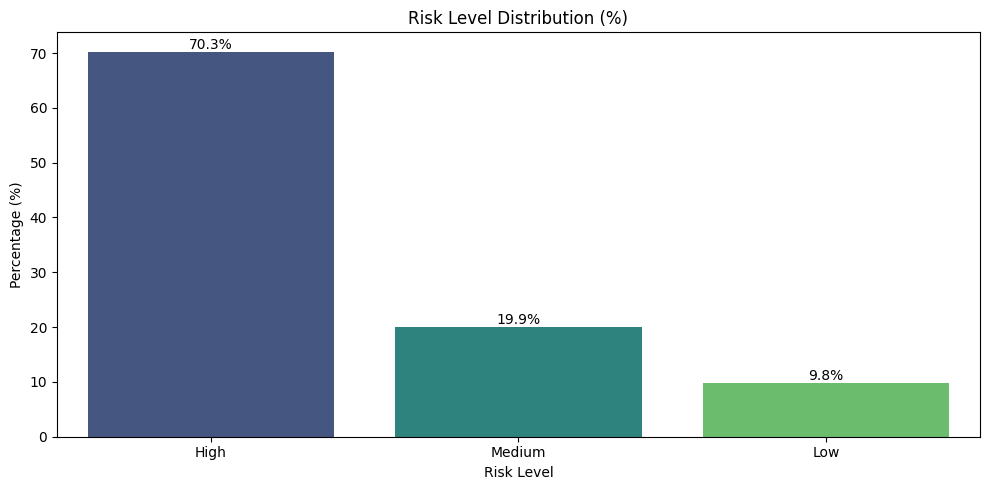

In [508]:
# Calculate percentages
risk_pct = (
    final_df["risk_level"]
    .value_counts(normalize=True)   # gives proportion
    .mul(100)                      # convert to %
    .rename("percentage")
    .reset_index()
)

risk_pct.columns = ["risk_level", "percentage"]

# Plot
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=risk_pct,
    x="risk_level",
    y="percentage",
    order=risk_pct.sort_values("percentage", ascending=False)["risk_level"],
    palette="viridis"
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",   # format as %
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Risk Level Distribution (%)")
plt.xlabel("Risk Level")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

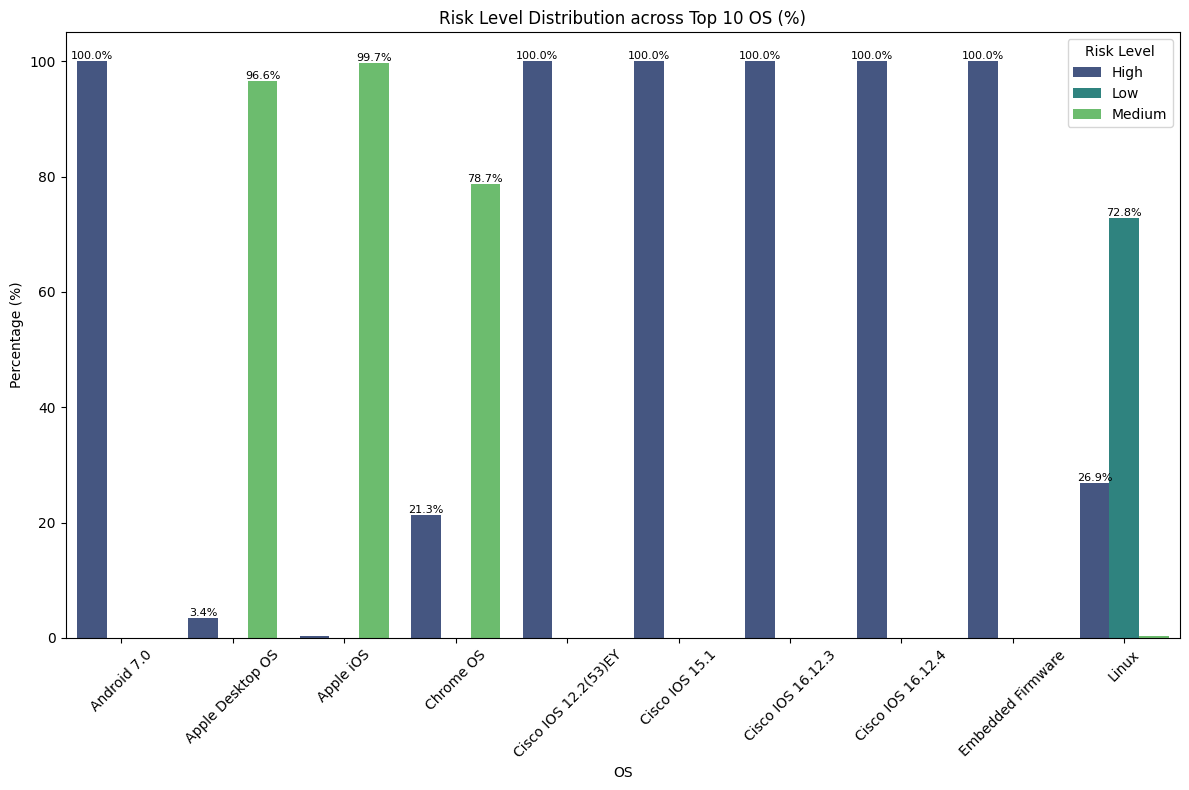

In [509]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Get Top 15 OS
# -----------------------------
top_os = final_df["OS"].value_counts().head(10).index

df_top = final_df[final_df["OS"].isin(top_os)]

# -----------------------------
# 2. Create percentage table
# -----------------------------
ct = pd.crosstab(df_top["OS"], df_top["risk_level"], normalize="index") * 100
ct = ct.reset_index()

# Convert to long format for seaborn
df_plot = ct.melt(id_vars="OS", var_name="risk_level", value_name="percentage")

# -----------------------------
# 3. Plot
# -----------------------------
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=df_plot,
    x="OS",
    y="percentage",
    hue="risk_level",
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Risk Level Distribution across Top 10 OS (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("OS")

# -----------------------------
# 4. Add percentage labels
# -----------------------------
for p in ax.patches:
    height = p.get_height()
    if height > 2:  # avoid clutter
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

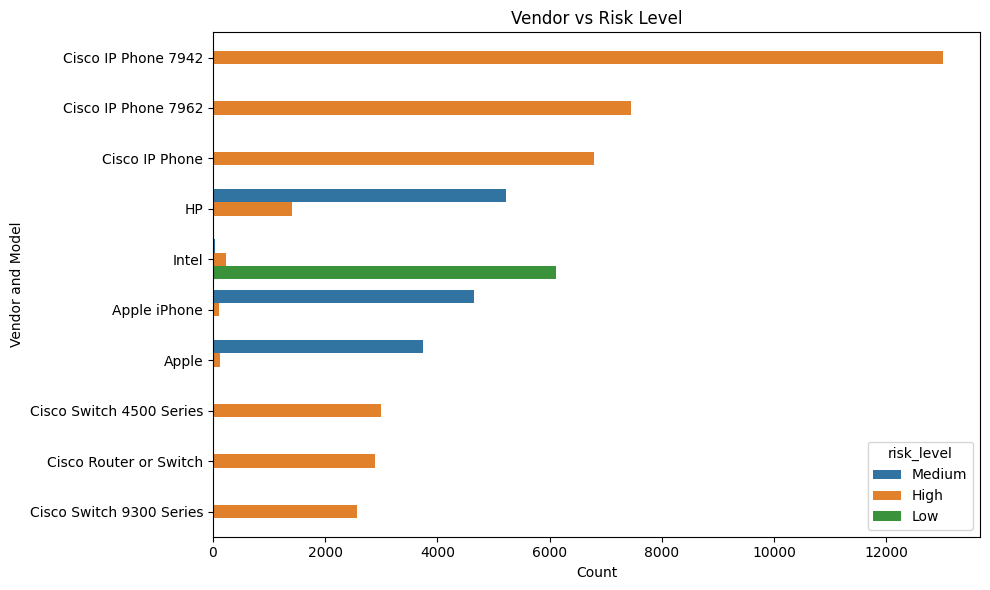

In [510]:
top_functions = final_df["Vendor and Model"].value_counts().head(10).index
filtered_df = final_df[final_df["Vendor and Model"].isin(top_functions)]

plt.figure(figsize=(10,6))

sns.countplot(
    data=filtered_df,
    y="Vendor and Model",   # 👈 switched to Y-axis
    hue="risk_level",
    order=top_functions
)

plt.title("Vendor vs Risk Level")
plt.xlabel("Count")
plt.ylabel("Vendor and Model")

plt.tight_layout()
plt.show()

## Idea 4 - Fingerprint Integrity Score

In [511]:
fp_cols = ['DHCP Options Fingerprint', 'DHCP Request Fingerprint','DHCP Vendor Class', 'DHCP Device Class']

def clean_fp_field(value):
    if pd.isna(value):
        return np.nan
    v = str(value).strip().lower()
    if v in ["","none","null","nan"]:
        return np.nan
    return value

for col in fp_cols:
    final_df[col] = final_df[col].apply(clean_fp_field)
for col in fp_cols:
    final_df[col + "_present"] = final_df[col].notnull().astype(int)
    

final_df["FP_Integrity_Score"] = final_df[[c for c in fp_cols ]].notnull().sum(axis=1)

In [512]:
final_df["FP_Integrity_Score"].value_counts()

FP_Integrity_Score
4    38018
0    26030
2    12806
3    11657
1        2
Name: count, dtype: int64

C:\Users\datas\AppData\Local\Temp\ipykernel_17152\2593652881.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


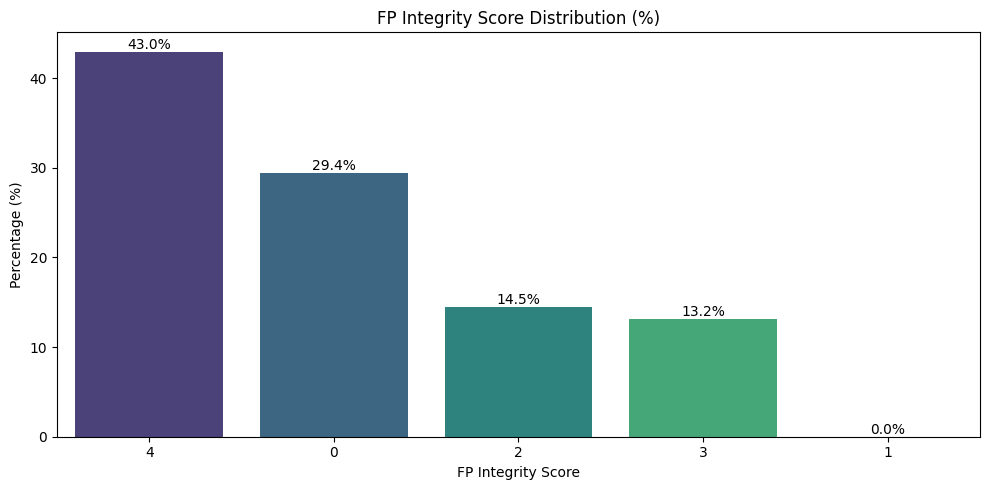

In [513]:
# Calculate percentages
intgrity_pct = (
    final_df["FP_Integrity_Score"]
    .value_counts(normalize=True)   # gives proportion
    .mul(100)                      # convert to %
    .rename("percentage")
    .reset_index()
)

intgrity_pct.columns = ["FP_Integrity_Score", "percentage"]

# Plot
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=intgrity_pct,
    x="FP_Integrity_Score",
    y="percentage",
    order=intgrity_pct.sort_values("percentage", ascending=False)["FP_Integrity_Score"],
    palette="viridis"
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",   # format as %
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("FP Integrity Score Distribution (%)")
plt.xlabel("FP Integrity Score")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

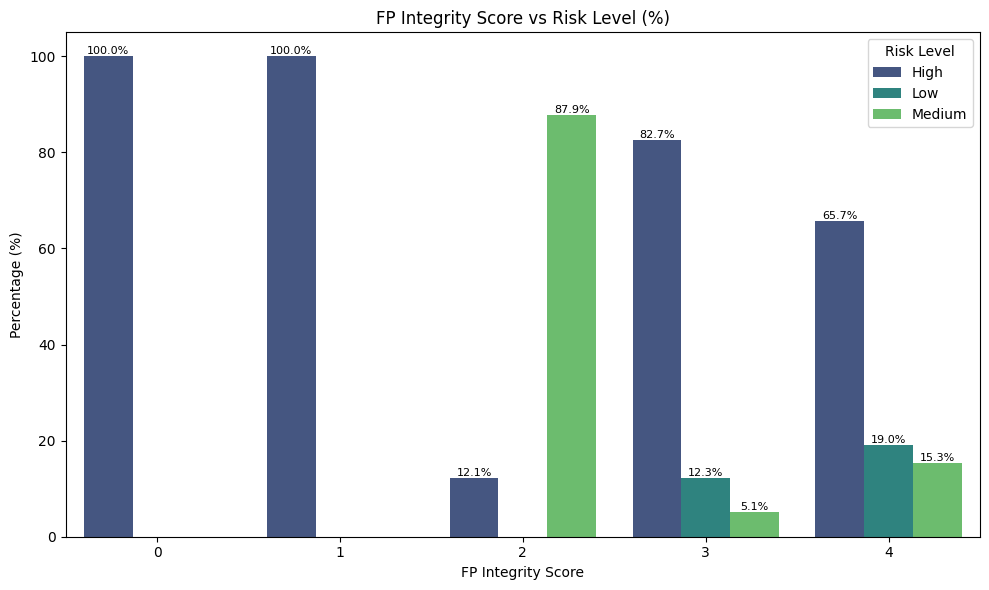

In [514]:
# -----------------------------
# 1. Create percentage table
# -----------------------------
ct = pd.crosstab(
    final_df["FP_Integrity_Score"],
    final_df["risk_level"],
    normalize="index"
) * 100

ct = ct.reset_index()

# Convert to long format
df_plot = ct.melt(
    id_vars="FP_Integrity_Score",
    var_name="risk_level",
    value_name="percentage"
)

# -----------------------------
# 2. Plot
# -----------------------------
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df_plot,
    x="FP_Integrity_Score",
    y="percentage",
    hue="risk_level",
    palette="viridis"
)

plt.title("FP Integrity Score vs Risk Level (%)")
plt.xlabel("FP Integrity Score")
plt.ylabel("Percentage (%)")

# -----------------------------
# 3. Add percentage labels
# -----------------------------
for p in ax.patches:
    height = p.get_height()
    if height > 3:  # avoid clutter
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

## Idea 5 - Model_type (Laptop/Smart phone/Tablet/Desktop/etc)

In [515]:
final_df.columns

Index(['id', 'Asset ID', 'MAC Address', 'OS', 'Function', 'Vendor and Model',
       'DHCP Options Fingerprint', 'DHCP Request Fingerprint',
       'DHCP Vendor Class', 'DHCP Device Class', 'DHCP_Opt_len',
       'DHCP_Req_len', 'OS_Vendor_mismatch', 'Function_Model_issue',
       'Category', 'vendor_normalized', 'OS_normalized', 'risk_level',
       'DHCP Options Fingerprint_present', 'DHCP Request Fingerprint_present',
       'DHCP Vendor Class_present', 'DHCP Device Class_present',
       'FP_Integrity_Score'],
      dtype='str')

In [516]:
final_df["Vendor and Model"].unique().tolist()

['Unknown',
 'Apple iPhone',
 'Apple',
 'Apple iPad',
 'Dell',
 'Apple Watch',
 'Multiple',
 'Belkin',
 'Apple iPod',
 'Apple iDevice',
 'Intel',
 'HP',
 'HP Printer',
 'Cisco Router 2900 Series',
 'Cisco Access Point',
 'Cisco',
 'LG',
 'LG TV',
 'Cisco IP Phone 7942',
 'Cisco IP Phone 7962',
 'Siemens',
 'Apple Mac Pro',
 'Texas Instruments',
 'American Power Conversion',
 'Cisco Router or Switch',
 'Cisco IP Phone',
 'Cisco TelePresence SX80 System',
 'Cisco TelePresence MX800ST System',
 'Cisco IP Phone 8821',
 'Cisco TelePresence MX300 G2 System',
 'BrainLab DICOM Proxy',
 'Samsung Galaxy Phone S Series',
 'Samsung',
 'Siemens syngo DICOM System',
 'Lexmark Printer',
 'Cisco Switch 4500 Series',
 'Cisco Switch 3750 Series',
 'Cisco IP Phone 7965',
 'Cisco Router 3900 Series',
 'GE MRI Scanner',
 'Sony',
 'HP Integrated Lights Out',
 'Apple MacBook',
 'Ricoh',
 nan,
 'Cisco IP Phone 8851',
 'Cisco Switch 9300 Series',
 'AzureWave',
 'AAEON Technology',
 'Biamp Systems',
 'Printroni

In [517]:
final_df["OS"].unique().tolist()

['Android 7.0',
 'Apple Desktop OS',
 'Debian',
 nan,
 'APC AOS',
 'Apple iOS',
 'Linux',
 'Chrome OS',
 'Cisco IOS 15.0',
 'Cisco IOS 15.3',
 'Cisco IOS 12.4',
 'Windows',
 'Linux Embedded',
 'Cisco IOS 12.2(53)EY',
 'Embedded Firmware',
 'Cisco IOS 15.1',
 'Cisco IOS 12.2(53)SE2',
 'VxWorks 6.5',
 'Cisco IOS 16.12.3',
 'Windows 10',
 'Android',
 'Windows Kernel 6.0',
 'Windows 10 Enterprise',
 'Apple',
 'Cisco IOS 16.12.4',
 'Cisco IOS 15.2',
 'Nut OS',
 'VxWorks',
 'Cisco AireOS 8.3',
 'Windows 7 Embedded Standard SP1',
 'Windows 10 Enterprise 2016 LTSB',
 'CentOS 7',
 'Raspbian']

In [518]:
def classify_model_type(row):
    
    vendor_model = str(row.get("Vendor and Model", "")).lower()
    function = str(row.get("Function", "")).lower()
    os_value = str(row.get("OS", "")).lower()
    vendor = str(row.get("vendor_normalized", "")).lower()

    # -----------------------------
    # 1. Handle Missing
    # -----------------------------
    if vendor_model in ["nan", "none", "", "unknown"]:
        return "Unknown"

    # -----------------------------
    # 2. Smartphones
    # -----------------------------
    if any(k in vendor_model for k in ["iphone", "galaxy", "pixel"]) or \
       ("android" in os_value and "tablet" not in vendor_model):
        return "Smartphone"

    # -----------------------------
    # 3. Tablets
    # -----------------------------
    if any(k in vendor_model for k in ["ipad", "tablet", "tab"]):
        return "Tablet"

    # -----------------------------
    # 4. Laptops
    # -----------------------------
    if any(k in vendor_model for k in ["macbook", "thinkpad", "latitude", "elitebook", "notebook"]) or \
       ("windows" in os_value and "laptop" in function):
        return "Laptop"

    # -----------------------------
    # 5. Desktops / Workstations
    # -----------------------------
    if any(k in vendor_model for k in ["imac", "desktop"]) or \
       any(k in function for k in ["workstation", "desktop"]):
        return "Desktop"

    # -----------------------------
    # 6. Servers
    # -----------------------------
    if "server" in function or "server" in vendor_model:
        return "Server"

    # -----------------------------
    # 7. Network Devices (VERY IMPORTANT)
    # -----------------------------
    if any(k in vendor_model for k in ["cisco", "aruba", "juniper", "router", "switch", "firewall"]) or \
       any(k in function for k in ["switch", "router", "firewall"]) or \
       any(k in os_value for k in ["cisco ios", "aireos"]):
        return "Network Device"

    # -----------------------------
    # 8. Medical Devices (NEW — based on your dataset)
    # -----------------------------
    if any(k in vendor_model for k in [
        "mri", "ct scanner", "dicom", "ultrasound", "patient monitoring"
    ]) or \
       any(k in vendor for k in ["siemens", "ge", "philips", "roche"]):
        return "Medical Device"

    # -----------------------------
    # 9. IoT / Embedded Devices
    # -----------------------------
    if any(k in os_value for k in ["vxworks", "embedded", "nut os"]) or \
       any(k in vendor_model for k in ["camera", "sensor", "iot"]) or \
       "embedded" in function:
        return "IoT Device"

    # -----------------------------
    # 10. Industrial / OT Devices
    # -----------------------------
    if any(k in vendor_model for k in ["automation", "control", "plc"]) or \
       any(k in function for k in ["plc", "hmi", "rtu", "dcs"]):
        return "OT Device"

    # -----------------------------
    # 11. OS-Based fallback
    # -----------------------------
    if "windows" in os_value or "linux" in os_value:
        return "IT Device"

    if "android" in os_value or "ios" in os_value:
        return "Mobile Device"

    return "Other"

In [519]:
final_df["Model_Type"] = final_df.apply(classify_model_type,axis = 1)

C:\Users\datas\AppData\Local\Temp\ipykernel_17152\424275993.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


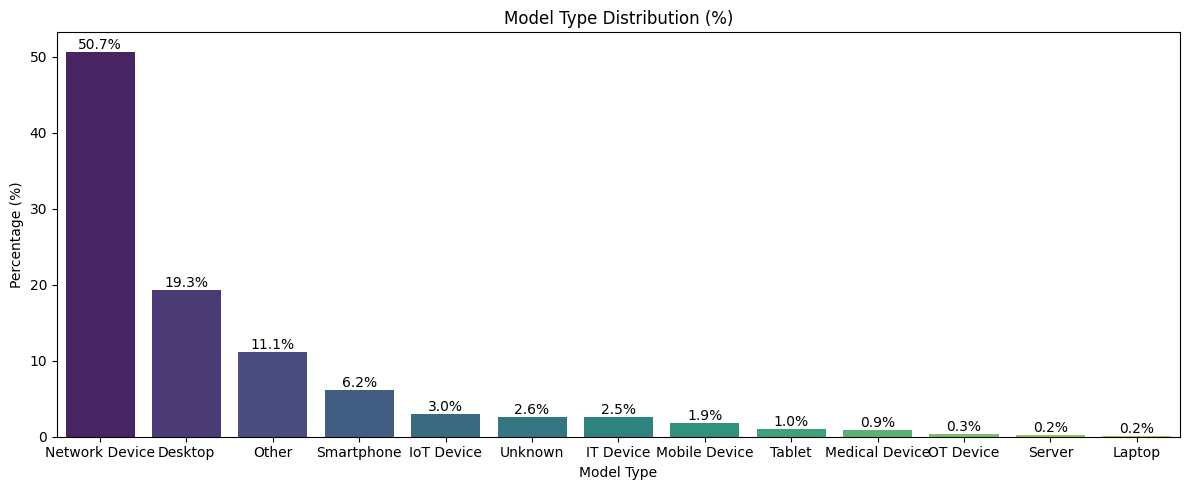

In [520]:
# Calculate percentages
model_type_pct = (
    final_df["Model_Type"]
    .value_counts(normalize=True)   # gives proportion
    .mul(100)                      # convert to %
    .rename("percentage")
    .reset_index()
)

model_type_pct.columns = ["Model_Type", "percentage"]

# Plot
plt.figure(figsize=(12,5))

ax = sns.barplot(
    data=model_type_pct,
    x="Model_Type",
    y="percentage",
    order=model_type_pct.sort_values("percentage", ascending=False)["Model_Type"],
    palette="viridis"
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",   # format as %
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Model Type Distribution (%)")
plt.xlabel("Model Type")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

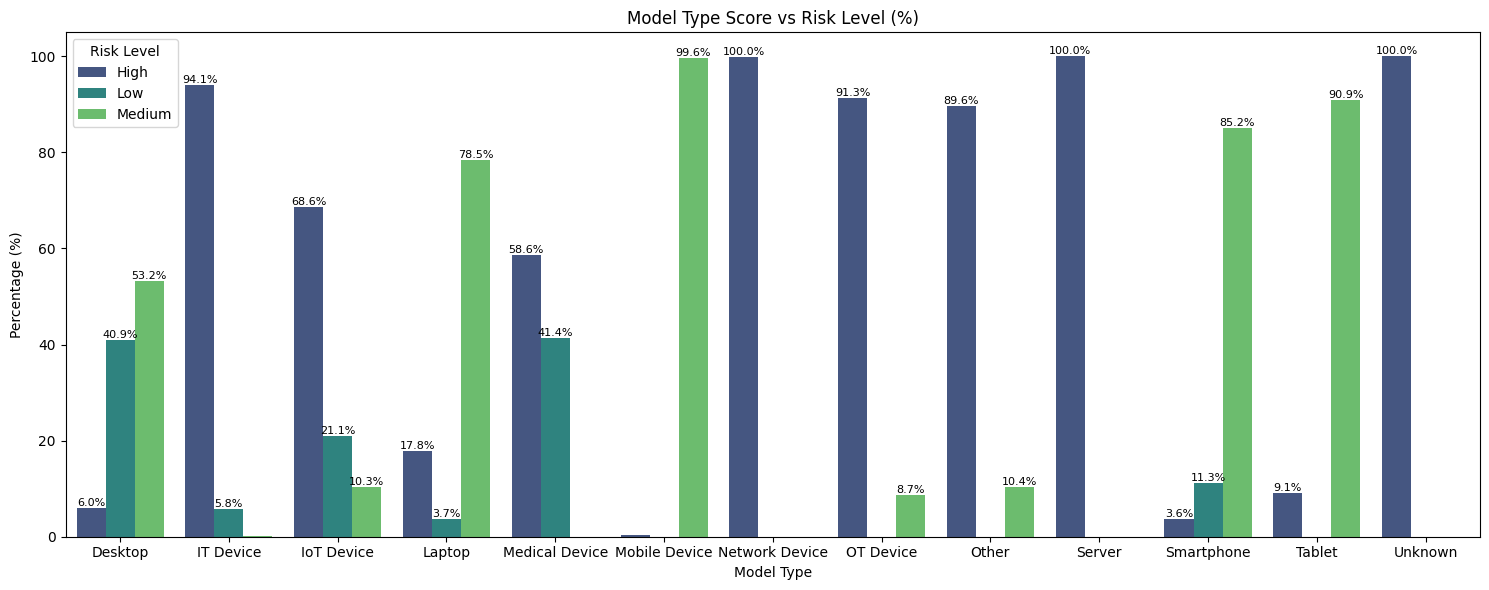

In [521]:
# -----------------------------
# 1. Create percentage table
# -----------------------------
ct = pd.crosstab(
    final_df["Model_Type"],
    final_df["risk_level"],
    normalize="index"
) * 100

ct = ct.reset_index()

# Convert to long format
df_plot = ct.melt(
    id_vars="Model_Type",
    var_name="risk_level",
    value_name="percentage"
)

# -----------------------------
# 2. Plot
# -----------------------------
plt.figure(figsize=(15,6))

ax = sns.barplot(
    data=df_plot,
    x="Model_Type",
    y="percentage",
    hue="risk_level",
    palette="viridis"
)

plt.title("Model Type Score vs Risk Level (%)")
plt.xlabel("Model Type")
plt.ylabel("Percentage (%)")

# -----------------------------
# 3. Add percentage labels
# -----------------------------
for p in ax.patches:
    height = p.get_height()
    if height > 3:  # avoid clutter
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

## Idea 6: Mobile Device Identification

In [522]:
def is_mobile(row):
    
    model_type = str(row.get("model_type", "")).lower()
    os_value = str(row.get("OS", "")).lower()
    
    # -----------------------------
    # 1. Direct model_type usage (BEST SIGNAL)
    # -----------------------------
    if model_type in ["smartphone", "tablet", "mobile device"]:
        return True

    # -----------------------------
    # 2. OS-based fallback
    # -----------------------------
    if any(k in os_value for k in ["android", "ios"]):
        return True

    # -----------------------------
    # 3. Otherwise
    # -----------------------------
    return False

In [523]:
final_df["Is_Mobile"] = final_df.apply(is_mobile,axis = 1)

In [524]:
final_df["Is_Mobile"].value_counts()

Is_Mobile
False    71104
True     17409
Name: count, dtype: int64

C:\Users\datas\AppData\Local\Temp\ipykernel_17152\3447312746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


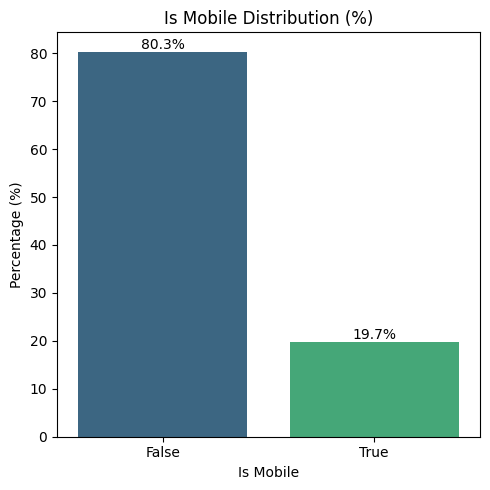

In [525]:
# Calculate percentages
is_mobile_pct = (
    final_df["Is_Mobile"]
    .value_counts(normalize=True)   # gives proportion
    .mul(100)                      # convert to %
    .rename("percentage")
    .reset_index()
)

is_mobile_pct.columns = ["Is_Mobile", "percentage"]

# Plot
plt.figure(figsize=(5,5))

ax = sns.barplot(
    data=is_mobile_pct,
    x="Is_Mobile",
    y="percentage",
    order=is_mobile_pct.sort_values("percentage", ascending=False)["Is_Mobile"],
    palette="viridis"
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",   # format as %
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Is Mobile Distribution (%)")
plt.xlabel("Is Mobile")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

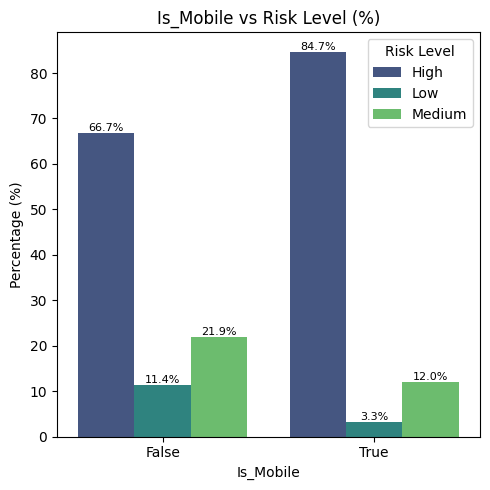

In [526]:
# -----------------------------
# 1. Create percentage table
# -----------------------------
ct = pd.crosstab(
    final_df["Is_Mobile"],
    final_df["risk_level"],
    normalize="index"
) * 100

ct = ct.reset_index()

# Convert to long format
df_plot = ct.melt(
    id_vars="Is_Mobile",
    var_name="risk_level",
    value_name="percentage"
)

# -----------------------------
# 2. Plot
# -----------------------------
plt.figure(figsize=(5,5))

ax = sns.barplot(
    data=df_plot,
    x="Is_Mobile",
    y="percentage",
    hue="risk_level",
    palette="viridis"
)

plt.title("Is_Mobile vs Risk Level (%)")
plt.xlabel("Is_Mobile")
plt.ylabel("Percentage (%)")

# -----------------------------
# 3. Add percentage labels
# -----------------------------
for p in ax.patches:
    height = p.get_height()
    if height > 3:  # avoid clutter
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

# Inconsistency and anomaly detection 

In [527]:
# Normalization helpers

def normalize_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

## Cross-field Consistency Checks

###  OS-Vendor Mismatch Detection

In [528]:
# Map vendor patterns to allowed OS patterns
allowed_os = {
    "apple": ["apple desktop os", "apple ios", "macos", "ios", "os x"],  # including general terms
    "samsung": ["android", "tizen"],
    "cisco": ["cisco ios", "cisco aireos", "apc aos"],  # network devices
    "apc": ["apc aos", "embedded firmware"],
    "linux": ["linux", "linux embedded", "debian", "centos", "raspbian"],
    "windows": ["windows", "windows 10", "windows 7", "windows kernel"],
    "vxworks": ["vxworks"],
    "nut": ["nut os"],
    "embedded": ["embedded firmware"]
}

In [529]:
vendor = final_df["Vendor and Model"].fillna("").str.lower()
os_val = final_df["OS"].fillna("").str.lower()

In [530]:
def detect_os_vendor_mismatch(df):
    vendor = df["Vendor and Model"].fillna("").str.lower()
    os_val = df["OS"].fillna("").str.lower()
    
    mismatch = np.zeros(len(df), dtype=bool)
    
    for v_pattern, allowed in allowed_os.items():
        # Rows where vendor matches this pattern
        vendor_mask = vendor.str.contains(v_pattern)
        
        # OS does NOT match any of the allowed OS for this vendor
        os_mask = ~os_val.apply(lambda x: any(a in x for a in allowed))
        
        mismatch |= (vendor_mask & os_mask)
    
    # Optional: treat 'unknown' vendor as suspicious if OS is very specific
    unknown_mask = vendor.str.contains("unknown")
    suspicious_os_mask = os_val.str.contains("ios|android|windows|linux")
    mismatch |= (unknown_mask & suspicious_os_mask)
    
    return mismatch

In [531]:
final_df["Err_OS_Vendor_Mismatch"] = detect_os_vendor_mismatch(final_df)

In [532]:
final_df["Err_OS_Vendor_Mismatch"].value_counts()

Err_OS_Vendor_Mismatch
False    54785
True     33728
Name: count, dtype: int64

In [533]:
def get_os_vendor_mismatch_reason(df):
    vendor = df["Vendor and Model"].fillna("").str.lower()
    os_val = df["OS"].fillna("").str.lower()

    conditions = [
        # Apple mismatch
        (vendor.str.contains("apple") & ~os_val.str.contains("ios|apple|mac")),
        
        # Samsung mismatch
        (vendor.str.contains("samsung") & ~os_val.str.contains("android")),
        
        # Cisco mismatch
        (vendor.str.contains("cisco") & ~os_val.str.contains("cisco ios|aireos")),
        
        # Windows on non-compute devices
        (vendor.str.contains("printer|camera|scanner") & os_val.str.contains("windows")),
        
        # Embedded OS mismatch
        (os_val.str.contains("vxworks|nut os|embedded") & 
         ~vendor.str.contains("industrial|iot|network|cisco")),
        
        # Unknown vendor but specific OS
        (vendor.str.contains("unknown") & 
         os_val.str.contains("ios|android|windows|linux"))
    ]

    choices = [
        "Apple device running non-Apple OS",
        "Samsung device running non-Android OS",
        "Cisco/network device running non-network OS",
        "Non-compute device running Windows",
        "Embedded OS inconsistent with vendor type",
        "Unknown vendor with specific OS"
    ]

    return np.select(conditions, choices, default=None)

In [534]:
final_df["OS_Vendor_reason"] = get_os_vendor_mismatch_reason(final_df)

In [535]:
final_df["OS_Vendor_reason"] = final_df["OS_Vendor_reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_OS_Vendor_Mismatch"],
    final_df["OS_Vendor_reason"]
)

OS_Vendor_reason,Apple device running non-Apple OS,Cisco/network device running non-network OS,Embedded OS inconsistent with vendor type,No Error,Samsung device running non-Android OS,Unknown vendor with specific OS
Err_OS_Vendor_Mismatch,,,,,,
False,0,0,2067,52718,0,0
True,874,30265,0,109,163,2317


### Function-Model mismatch

In [536]:
def detect_function_model_mismatch(df):
    f = df["Function"].fillna("").str.lower()
    vm = df["Vendor and Model"].fillna("").str.lower()

    mismatch = (

        # 1. Computer/Workstation should not be mobile devices
        (f.str.contains("computer|workstation|desktop|laptop") & 
         vm.str.contains("iphone|ipad|watch|smartphone|galaxy|tablet")) |

        # 2. Mobile devices should not be computers/servers
        (f.str.contains("smartphone|mobile|tablet|smartwatch") & 
         vm.str.contains("dell|hp|lenovo|pc|macbook|server")) |

        # 3. Network devices should not be consumer/mobile devices
        (f.str.contains("router|switch|firewall|wireless|network") & 
         vm.str.contains("iphone|ipad|galaxy|smartphone|watch|tv")) |

        # 4. IP Phones / VoIP should not be computers or mobile phones
        (f.str.contains("ip phone|voip") & 
         vm.str.contains("laptop|desktop|pc|macbook|iphone|android")) |

        # 5. Printers should not be mobile/computing devices
        (f.str.contains("printer") & 
         vm.str.contains("iphone|ipad|galaxy|laptop|desktop|pc")) |

        # 6. Medical devices should not be IT/mobile devices
        (f.str.contains("mri|ct|scanner|medical|imaging|ultrasound") & 
         vm.str.contains("iphone|ipad|laptop|desktop|pc|android")) |

        # 7. Smart TV / Streaming devices mismatch
        (f.str.contains("tv|streaming|media") & 
         ~vm.str.contains("tv|roku|apple tv|samsung tv")) |

        # 8. IP Camera / Surveillance mismatch
        (f.str.contains("camera|surveillance") & 
         ~vm.str.contains("axis|hikvision|sony|camera")) |

        # 9. Networking function but vendor is clearly compute device
        (f.str.contains("networking") & 
         vm.str.contains("dell xps|macbook|hp pc")) |

        # 10. Unknown function but highly specific vendor (suspicious)
        (f.str.contains("unknown") & 
         vm.str.contains("cisco|apple|samsung|hp|dell"))
    )

    return mismatch

In [537]:
final_df["Err_Function_Model_Mismatch"] = detect_function_model_mismatch(final_df)

In [538]:
def detect_function_model_reason(df):
    f = df["Function"].fillna("").str.lower()
    vm = df["Vendor and Model"].fillna("").str.lower()

    conditions = [

        # 1. Computer/Workstation vs Mobile
        (f.str.contains("computer|workstation|desktop|laptop") & 
         vm.str.contains("iphone|ipad|watch|smartphone|galaxy|tablet")),

        # 2. Mobile vs Computer
        (f.str.contains("smartphone|mobile|tablet|smartwatch") & 
         vm.str.contains("dell|hp|lenovo|pc|macbook|server")),

        # 3. Network vs Mobile
        (f.str.contains("router|switch|firewall|wireless|network") & 
         vm.str.contains("iphone|ipad|galaxy|smartphone|watch|tv")),

        # 4. IP Phone / VoIP mismatch
        (f.str.contains("ip phone|voip") & 
         vm.str.contains("laptop|desktop|pc|macbook|iphone|android")),

        # 5. Printer mismatch
        (f.str.contains("printer") & 
         vm.str.contains("iphone|ipad|galaxy|laptop|desktop|pc")),

        # 6. Medical device mismatch
        (f.str.contains("mri|ct|scanner|medical|imaging|ultrasound") & 
         vm.str.contains("iphone|ipad|laptop|desktop|pc|android")),

        # 7. Smart TV / Streaming mismatch
        (f.str.contains("tv|streaming|media") & 
         ~vm.str.contains("tv|roku|apple tv|samsung tv")),

        # 8. Camera / Surveillance mismatch
        (f.str.contains("camera|surveillance") & 
         ~vm.str.contains("axis|hikvision|sony|camera")),

        # 9. Networking function but compute vendor
        (f.str.contains("networking") & 
         vm.str.contains("dell xps|macbook|hp pc")),

        # 10. Unknown function but specific vendor
        (f.str.contains("unknown") & 
         vm.str.contains("cisco|apple|samsung|hp|dell"))
    ]

    choices = [
        "Computer/workstation classified as mobile device",
        "Mobile device classified as computer/server",
        "Network device classified as mobile/consumer device",
        "IP phone classified as compute/mobile device",
        "Printer classified as compute/mobile device",
        "Medical device classified as IT/mobile device",
        "Streaming/TV function with non-TV vendor",
        "Camera/surveillance function with non-camera vendor",
        "Networking function assigned to compute device",
        "Unknown function with clearly identifiable vendor"
    ]

    return np.select(conditions, choices, default=None)

In [539]:
final_df["Function_Model_reason"] = detect_function_model_reason(final_df)

In [540]:
final_df["Function_Model_reason"] = final_df["Function_Model_reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_Function_Model_Mismatch"],
    final_df["Function_Model_reason"]
)

Function_Model_reason,Camera/surveillance function with non-camera vendor,Computer/workstation classified as mobile device,IP phone classified as compute/mobile device,Mobile device classified as computer/server,No Error,Streaming/TV function with non-TV vendor,Unknown function with clearly identifiable vendor
Err_Function_Model_Mismatch,,,,,,,
False,0,0,0,0,87374,0,0
True,1,1008,4,1,0,114,11


### Category–Function mismatch

In [541]:
def detect_category_function_mismatch(df):
    f = df["Function"].fillna("").str.lower()
    c = df["Category"].fillna("").str.lower()

    mismatch = (

        # IT category should not have network/medical/iot functions
        (c.str.contains("it") & 
         f.str.contains("router|switch|firewall|camera|iot|sensor|mri|ct|scanner|ultrasound")) |

        # Network category should only have network-related functions
        (c.str.contains("network") & 
         ~f.str.contains("router|switch|firewall|wireless|network|access point")) |

        # IoT category mismatch
        (c.str.contains("iot") & 
         ~f.str.contains("camera|sensor|smart|tv|iot|device|monitoring")) |

        # Medical category mismatch
        (c.str.contains("medical") & 
         ~f.str.contains("mri|ct|scanner|ultrasound|patient|medical|imaging|diagnostic")) |

        # Unknown category but function is clearly identifiable
        (c.str.contains("unknown") & 
         f.str.contains("computer|router|switch|printer|mri|camera"))
    )

    return mismatch

In [542]:
def detect_category_function_reason(df):
    f = df["Function"].fillna("").str.lower()
    c = df["Category"].fillna("").str.lower()

    conditions = [

        # IT mismatch
        (c.str.contains("it") & 
         f.str.contains("router|switch|firewall|camera|mri|ct|scanner")),

        # Network mismatch
        (c.str.contains("network") & 
         ~f.str.contains("router|switch|firewall|wireless|network|access point")),

        # IoT mismatch
        (c.str.contains("iot") & 
         ~f.str.contains("camera|sensor|smart|tv|iot|device")),

        # Medical mismatch
        (c.str.contains("medical") & 
         ~f.str.contains("mri|ct|scanner|ultrasound|patient|medical|imaging")),

        # Unknown category mismatch
        (c.str.contains("unknown") & 
         f.str.contains("computer|router|switch|printer|mri|camera"))
    ]

    choices = [
        "IT category assigned to network/medical/IoT device",
        "Non-network function classified as network device",
        "Function not consistent with IoT category",
        "Non-medical function classified as medical device",
        "Known function assigned to unknown category"
    ]

    return np.select(conditions, choices, default=None)

In [543]:
final_df["Err_Category_Function_Mismatch"] = detect_category_function_mismatch(final_df)

final_df["Category_Function_Reason"] = detect_category_function_reason(final_df)

In [544]:
final_df["Category_Function_Reason"] = final_df["Category_Function_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_Category_Function_Mismatch"],
    final_df["Category_Function_Reason"]
)

Category_Function_Reason,Function not consistent with IoT category,No Error,Non-medical function classified as medical device
Err_Category_Function_Mismatch,,,
False,25,42008,0
True,46478,0,2


### MAC OUI–Vendor mismatch

In [545]:
def extract_oui(mac):
    if pd.isna(mac):
        return ""
    mac = str(mac).upper().replace(":", "").replace("-", "")
    return mac[:6]

In [546]:
OUI_VENDOR_MAP = {
    # Apple devices
    "001A11": "Apple",
    "3C5A37": "Apple",
    "F4F951": "Apple",

    # Cisco / Networking
    "FCFBFB": "Cisco",
    "000142": "Cisco",
    "001B0C": "Cisco",

    # HP / Dell / IBM
    "001B63": "HP",
    "A0B1C2": "Dell",
    "00E04C": "IBM",

    # VMware / Virtualization
    "000C29": "VMware",

    # Netgear / Aruba / Juniper
    "000FB5": "Netgear",
    "AC162D": "Aruba",
    "0022B0": "Juniper",

    # Samsung / LG / Sony / Philips
    "3C8BFE": "Samsung",
    "001E7D": "LG",
    "0016B6": "Sony",
    "000D6F": "Philips",

    # Fortinet / Palo Alto / Microsoft
    "001C0F": "Fortinet",
    "080027": "Microsoft"
}

In [547]:
def detect_mac_vendor_mismatch(df):

    mac_oui = df["MAC Address"].apply(extract_oui)

    vendor = df["vendor_normalized"].fillna("").str.strip()

    expected_vendor = mac_oui.map(OUI_VENDOR_MAP).fillna("")

    mismatch = (
        # only evaluate when we actually know expected vendor
        (expected_vendor != "") &

        # ignore Unknown / Other cases (no ground truth)
        (~vendor.str.lower().isin(["unknown", "other"])) &

        # mismatch condition
        (vendor != expected_vendor)
    )

    return mismatch

In [548]:
def detect_mac_vendor_reason(df):

    mac_oui = df["MAC Address"].apply(extract_oui)

    vendor = df["vendor_normalized"].fillna("").str.strip()
    expected_vendor = mac_oui.map(OUI_VENDOR_MAP).fillna("")

    conditions = [

        # Known OUI but vendor mismatch
        (expected_vendor != "") &
        (~vendor.str.lower().isin(["unknown", "other"])) &
        (vendor != expected_vendor),

        # OUI not mapped
        (expected_vendor == "") &
        (~vendor.str.lower().isin(["unknown", "other"]))
    ]

    choices = [
        "MAC OUI vendor does not match assigned vendor_normalized",
        "MAC OUI not mapped to known vendor"
    ]

    return np.select(conditions, choices, default=None)

In [549]:
final_df["Err_MAC_Vendor_Mismatch"] = detect_mac_vendor_mismatch(final_df)
final_df["MAC_Vendor_Reason"] = detect_mac_vendor_reason(final_df)

In [550]:
final_df["MAC_Vendor_Reason"] = final_df["MAC_Vendor_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_MAC_Vendor_Mismatch"],
    final_df["MAC_Vendor_Reason"]
)

MAC_Vendor_Reason,MAC OUI not mapped to known vendor,MAC OUI vendor does not match assigned vendor_normalized,No Error
Err_MAC_Vendor_Mismatch,,,
False,70199,0,18311
True,0,3,0


### DHCP Vendor Class vs Vendor mismatch

In [551]:
def normalize_dhcp_vendor(v):

    if pd.isna(v):
        return "unknown"

    v = str(v).lower()

    # Cisco
    if "cisco" in v:
        return "cisco"

    # HP
    if "hp" in v or "hewlett-packard" in v:
        return "hp"

    # Apple (rare in DHCP but safe rule)
    if "apple" in v:
        return "apple"

    # Aruba
    if "aruba" in v:
        return "aruba"

    # Samsung / Android ecosystem
    if "android" in v or "samsung" in v:
        return "samsung"

    # Zebra
    if "zebra" in v:
        return "zebra"

    # Axis cameras
    if "axis" in v:
        return "sony"  # or "other" depending on your taxonomy

    # Fortinet
    if "forti" in v:
        return "fortinet"

    # Microsoft / Windows PXE
    if "msft" in v or "microsoft" in v or "pxe" in v:
        return "microsoft"

    # Linux / DHCP clients → not vendor
    if "dhcp" in v or "udhc" in v or "dhcpcd" in v or "linux" in v:
        return "unknown"

    return "other"

In [552]:
def detect_dhcp_vendor_mismatch(df):

    dhcp_vendor = df["DHCP Vendor Class"].apply(normalize_dhcp_vendor)
    expected_vendor = df["vendor_normalized"].fillna("unknown").str.lower()

    mismatch = (
        (dhcp_vendor != "unknown") &
        (expected_vendor != "unknown") &
        (dhcp_vendor != expected_vendor)
    )

    return mismatch

In [553]:
def detect_dhcp_vendor_reason(df):

    dhcp_vendor = df["DHCP Vendor Class"].apply(normalize_dhcp_vendor)
    expected_vendor = df["vendor_normalized"].fillna("unknown").str.lower()

    conditions = [

        # Known DHCP vendor but mismatch
        (dhcp_vendor != "unknown") &
        (expected_vendor != "unknown") &
        (dhcp_vendor != expected_vendor),

        # DHCP value is not a vendor signal (OS / protocol / client string)
        (dhcp_vendor == "unknown") &
        (df["DHCP Vendor Class"].notna())
    ]

    choices = [
        "DHCP vendor class does not match vendor_normalized",
        "DHCP vendor class is OS/protocol identifier, not a valid vendor"
    ]

    return np.select(conditions, choices, default=None)

In [554]:
final_df["Err_DHCP_Vendor_Mismatch"] = detect_dhcp_vendor_mismatch(final_df)
final_df["DHCP_Vendor_Reason"] = detect_dhcp_vendor_reason(final_df)

In [555]:
final_df["DHCP_Vendor_Reason"] = final_df["DHCP_Vendor_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_DHCP_Vendor_Mismatch"],
    final_df["DHCP_Vendor_Reason"]
)

DHCP_Vendor_Reason,DHCP vendor class does not match vendor_normalized,"DHCP vendor class is OS/protocol identifier, not a valid vendor",No Error
Err_DHCP_Vendor_Mismatch,,,
False,0,1325,72610
True,14578,0,0


## Schema & Format Validation

### Mac Address validation

In [556]:
def detect_invalid_mac(df):

    mac_clean = (
        df["MAC Address"]
        .fillna("")
        .str.lower()
        .str.replace(":", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip()
    )

    # Step 1: format validation
    valid_format = mac_clean.str.match(r"^[0-9a-f]{12}$")

    # Step 2: remove clearly invalid MAC patterns
    invalid_patterns = (
        (mac_clean == "0" * 12) |          # all zeros
        (mac_clean == "f" * 12) |          # broadcast-like
        (mac_clean.str.contains(r"^feedad", na=False)) |  # synthetic/test pattern
        (mac_clean.str.contains(r"^deadbe", na=False))     # common fake pattern
    )

    return ~valid_format | invalid_patterns

In [557]:
final_df["Err_Invalid_MAC"] = detect_invalid_mac(final_df)

In [558]:
final_df["Err_Invalid_MAC"].value_counts()

Err_Invalid_MAC
False    88016
True       497
Name: count, dtype: int64

In [559]:
def detect_invalid_mac_reason(df):

    mac_clean = (
        df["MAC Address"]
        .fillna("")
        .str.lower()
        .str.replace(":", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip()
    )

    valid_format = mac_clean.str.match(r"^[0-9a-f]{12}$")

    conditions = [
        ~valid_format,
        mac_clean == "0" * 12,
        mac_clean.str.contains(r"^feedad", na=False),
        mac_clean.str.contains(r"^deadbe", na=False)
    ]

    choices = [
        "Invalid MAC format (not 12 hex characters)",
        "MAC is all-zero placeholder value",
        "Synthetic/test MAC pattern detected (feedad*)",
        "Synthetic MAC pattern detected (deadbe*)"
    ]

    return np.select(conditions, choices, default=None)

In [560]:
final_df["Invalid_Mac_Reason"] = detect_invalid_mac_reason(final_df)

In [561]:
final_df["Invalid_Mac_Reason"] = final_df["Invalid_Mac_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_Invalid_MAC"],
    final_df["Invalid_Mac_Reason"]
)

Invalid_Mac_Reason,Invalid MAC format (not 12 hex characters),No Error,Synthetic/test MAC pattern detected (feedad*)
Err_Invalid_MAC,,,
False,0,88016,0
True,496,0,1


### Duplicate MAC Detection

In [562]:
mac_clean = (
    final_df["MAC Address"]
    .fillna("")
    .str.lower()
    .str.replace(":", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

In [563]:
final_df["Err_Duplicate_MAC"] = mac_clean.duplicated(keep=False)

In [564]:
mac_counts = mac_clean.value_counts()

mac_counts[mac_counts > 1]

MAC Address
186024000000    2
346288000000    2
382000000000    2
382056000000    2
508140000000    2
703509000000    2
887556000000    2
Name: count, dtype: int64

In [565]:
final_df["Err_Duplicate_MAC"].value_counts()

Err_Duplicate_MAC
False    88499
True        14
Name: count, dtype: int64

In [566]:
def detect_duplicate_mac_reason(df):
    mac = (
        df["MAC Address"]
        .fillna("")
        .str.lower()
        .str.replace(":", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip()
    )

    df = df.copy()
    df["mac_clean"] = mac

    dup_mask = df["mac_clean"].duplicated(keep=False)

    reasons = []

    for _, row in df.iterrows():
        if not dup_mask.loc[_]:
            reasons.append(None)
            continue

        mac_val = row["mac_clean"]

        if mac_val in ["000000000000", "feedad000000", ""]:
            reasons.append("Placeholder MAC reused across records")

        elif row["Vendor and Model"] and row["Function"]:
            reasons.append("Same MAC used across multiple asset contexts")

        else:
            reasons.append("Duplicate MAC detected - requires validation")

    return reasons

In [567]:
final_df["Duplicate_Mac_Reason"] = detect_duplicate_mac_reason(final_df)

In [568]:
final_df["Duplicate_Mac_Reason"] = final_df["Duplicate_Mac_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_Duplicate_MAC"],
    final_df["Invalid_Mac_Reason"]
)

Invalid_Mac_Reason,Invalid MAC format (not 12 hex characters),No Error,Synthetic/test MAC pattern detected (feedad*)
Err_Duplicate_MAC,,,
False,496,88002,1
True,0,14,0


### Validating OS format

In [569]:
def detect_os_format_validation(df):

    os = df["OS"].fillna("").astype(str).str.lower().str.strip()

    conditions = [
        (os == ""),
        (os.isin(["unknown", "na", "n/a", "none", "null"])),
        (os.str.len() < 3),
        (os.str.contains("dhcp|pxeclient|bootp|httpclient|udhcpc|dhcpcd", na=False)),
        (os.str.contains(r"[^\w\s\.\-\/]", na=False)),
        (os.str.contains("msft 5\.0|cisco ap|aruba|hp jetdirect", na=False))
    ]

    reasons = [
        "Missing OS value",
        "Generic or placeholder OS",
        "OS value too short / invalid format",
        "Network boot / DHCP artifact instead of OS",
        "Corrupted or noisy OS format",
        "Vendor/DHCP class incorrectly stored as OS"
    ]

    df = df.copy()

    df["Err_OS_Format"] = np.select(conditions, [True]*len(conditions), default=False)
    df["OS_Format_Reason"] = np.select(conditions, reasons, default=None)

    return df

<>:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\datas\AppData\Local\Temp\ipykernel_17152\1932840427.py:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  (os.str.contains("msft 5\.0|cisco ap|aruba|hp jetdirect", na=False))


In [570]:
final_df = detect_os_format_validation(final_df)

In [571]:
final_df["Err_OS_Format"].value_counts()

Err_OS_Format
False    54341
True     34172
Name: count, dtype: int64

In [572]:
final_df["OS_Format_Reason"].value_counts(dropna=False)

OS_Format_Reason
NaN                             54341
Missing OS value                31212
Corrupted or noisy OS format     2960
Name: count, dtype: int64

In [573]:
final_df["OS_Format_Reason"] = final_df["OS_Format_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_OS_Format"],
    final_df["OS_Format_Reason"]
)

OS_Format_Reason,Corrupted or noisy OS format,Missing OS value,No Error
Err_OS_Format,,,
False,0,0,54341
True,2960,31212,0


In [574]:
fp_cols = ['DHCP Options Fingerprint', 'DHCP Request Fingerprint','DHCP Vendor Class', 'DHCP Device Class']
final_df["Err_All_Fingerprints_Missing"] = final_df[fp_cols].isnull().all(axis=1)

##  Device Identity & Uniqueness Checks

### Conflicting attributes (Same MAC,Different Identity)

In [575]:
conflicts_check = (
    final_df.groupby("MAC Address")
    .agg(
        os_count=("OS", lambda x: x.dropna().nunique()),
        vendor_count=("Vendor and Model", lambda x: x.dropna().nunique()),
        function_count=("Function", lambda x: x.dropna().nunique()),
        category_count=("Category", lambda x: x.dropna().nunique())
    )
    .reset_index()
)

# Flag conflict
conflicts_check["Err_Conflicting_Identity"] = (
    (conflicts_check["os_count"] > 1) |
    (conflicts_check["vendor_count"] > 1) |
    (conflicts_check["function_count"] > 1) |
    (conflicts_check["category_count"] > 1)
)

# Add reason (VERY IMPORTANT for PPT / audit)
conflicts_check["Conflicting_Identity_Reason"] = np.select(
    [
        conflicts_check["os_count"] > 1,
        conflicts_check["vendor_count"] > 1,
        conflicts_check["function_count"] > 1,
        conflicts_check["category_count"] > 1
    ],
    [
        "Same MAC mapped to multiple OS values",
        "Same MAC mapped to multiple vendors/models",
        "Same MAC mapped to multiple functions",
        "Same MAC mapped to multiple categories"
    ],
    default=None
)

# Merge back safely
final_df = final_df.merge(
    conflicts_check[[
        "MAC Address",
        "Err_Conflicting_Identity",
        "Conflicting_Identity_Reason"
    ]],
    on="MAC Address",
    how="left"
)

In [576]:
final_df["Err_Conflicting_Identity"].value_counts()

Err_Conflicting_Identity
False    88509
True         4
Name: count, dtype: int64

In [577]:
final_df["Conflicting_Identity_Reason"].value_counts()

Conflicting_Identity_Reason
Same MAC mapped to multiple vendors/models    4
Name: count, dtype: int64

### Duplicate Fingerprint analysis

In [578]:
# Step 1: Create normalized fingerprint columns
fp_df = final_df.copy()

fp_df["fp_key"] = (
    fp_df["DHCP Options Fingerprint"].fillna("").astype(str).str.lower().str.strip() + "|" +
    fp_df["DHCP Request Fingerprint"].fillna("").astype(str).str.lower().str.strip() + "|" +
    fp_df["DHCP Vendor Class"].fillna("").astype(str).str.lower().str.strip() + "|" +
    fp_df["DHCP Device Class"].fillna("").astype(str).str.lower().str.strip()
)

# Step 2: detect duplicates
fp_df["Err_Duplicate_Fingerprint"] = fp_df.duplicated(subset=["fp_key"], keep=False)

# Step 3: reason
fp_df["Fingerprint_Reason"] = fp_df["Err_Duplicate_Fingerprint"].map(
    lambda x: "Same network behavior fingerprint seen across multiple devices"
    if x else None
)

# Step 4: merge back if needed
final_df["Err_Duplicate_Fingerprint"] = fp_df["Err_Duplicate_Fingerprint"]
final_df["Fingerprint_Reason"] = fp_df["Fingerprint_Reason"]

In [579]:
final_df["Err_Duplicate_Fingerprint"].value_counts()

Err_Duplicate_Fingerprint
True     88384
False      129
Name: count, dtype: int64

In [580]:
final_df["Fingerprint_Reason"].value_counts()

Fingerprint_Reason
Same network behavior fingerprint seen across multiple devices    88384
Name: count, dtype: int64

## DHCP Fingerprint Analysis


### Fingerprint Grouping and clustering

In [581]:
final_df["fp_key"] = (
    final_df["DHCP Options Fingerprint"].fillna("").astype(str).str.lower().str.strip() + "|" +
    final_df["DHCP Request Fingerprint"].fillna("").astype(str).str.lower().str.strip() + "|" +
    final_df["DHCP Vendor Class"].fillna("").astype(str).str.lower().str.strip() + "|" +
    final_df["DHCP Device Class"].fillna("").astype(str).str.lower().str.strip()
)
fp_counts = final_df.groupby("fp_key")["fp_key"].transform("count")

final_df["Fingerprint_Group_Size"] = fp_counts

In [582]:
final_df["Fingerprint_Group_Size"].describe()

count    88513.000000
mean     11579.231876
std       9953.591546
min          1.000000
25%       3469.000000
50%       7168.000000
75%      26030.000000
max      26030.000000
Name: Fingerprint_Group_Size, dtype: float64

In [583]:
final_df["Fingerprint_Group_Size"].value_counts().head(10)

Fingerprint_Group_Size
26030    26030
12290    12290
7168      7168
6936      6936
6359      6359
4651      4651
3469      3469
2436      2436
2370      2370
1889      1889
Name: count, dtype: int64

In [584]:
final_df["fp_key"].value_counts().head(5)

fp_key
|||                                                                                                26030
53,61,12,60,55|1,66,6,3,15,150,35|cisco systems, inc. ip phone cp-7942g|voip phones/adapters       12290
53,61,12,60,55|1,66,6,3,15,150,35|cisco systems, inc. ip phone cp-7962g|voip phones/adapters        7168
53,61,12,60,55|1,3,6,15,31,33,43,44,46,47,119,121,249,252|msft 5.0|windows                          6936
53,61,12,60,55|1,3,6,15,35,66,150,2,7,42,43,58,59,159,160|cisco systems, inc. ip phone cp-8811|     6359
Name: count, dtype: int64

In [585]:
fp_cols = ['DHCP Options Fingerprint', 'DHCP Request Fingerprint','DHCP Vendor Class', 'DHCP Device Class'] 
final_df["Err_All_Fingerprints_Missing"] = final_df[fp_cols].isnull().all(axis=1)
final_df["Err_All_Fingerprints_Missing"].value_counts()

Err_All_Fingerprints_Missing
False    62483
True     26030
Name: count, dtype: int64

### DHCP Vendor Class vs Device Class Mismatch

In [586]:
import numpy as np

vc = final_df["DHCP Vendor Class"].fillna("").str.lower()
dc = final_df["DHCP Device Class"].fillna("").str.lower()

conditions = [
    # Cisco mismatch
    (vc.str.contains("cisco") & ~dc.str.contains("phone|ap|router|switch|cisco")),

    # Android mismatch
    (vc.str.contains("android") & ~dc.str.contains("mobile|phone|android")),

    # Printer mismatch
    (vc.str.contains("hp|lexmark|zebra") & ~dc.str.contains("printer")),

    # Microsoft mismatch
    (vc.str.contains("msft|windows") & ~dc.str.contains("pc|computer|windows"))
]

reasons = [
    "Cisco vendor class inconsistent with device class",
    "Android vendor class inconsistent with device type",
    "Printer vendor class inconsistent with device class",
    "Microsoft vendor class inconsistent with device class"
]

final_df["Err_DHCP_Class_Mismatch"] = np.select(conditions, [True]*len(conditions), default=False)
final_df["DHCP_Class_Reason"] = np.select(conditions, reasons, default=None)

In [587]:
final_df["DHCP_Class_Reason"] = final_df["OS_Format_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_DHCP_Class_Mismatch"],
    final_df["DHCP_Class_Reason"]
)

DHCP_Class_Reason,Corrupted or noisy OS format,Missing OS value,No Error
Err_DHCP_Class_Mismatch,,,
False,2960,31140,45524
True,0,72,8817


### DHCP Request Fingerprint Inconsistency


In [588]:
# DHCP Request Fingerprint Inconsistency

req_fp_check = (
    final_df.groupby("MAC Address")
    .agg(req_fp_count=("DHCP Request Fingerprint", lambda x: x.dropna().nunique()))
    .reset_index()
)

req_fp_check["Err_DHCP_Request_Inconsistency"] = req_fp_check["req_fp_count"] > 1

# Reason
req_fp_check["DHCP_Request_Reason"] = req_fp_check["Err_DHCP_Request_Inconsistency"].map(
    lambda x: "Multiple DHCP Request fingerprints observed for same MAC" if x else None
)

# Merge back
final_df = final_df.merge(
    req_fp_check[["MAC Address", "Err_DHCP_Request_Inconsistency", "DHCP_Request_Reason"]],
    on="MAC Address",
    how="left"
)

In [589]:
final_df["Err_DHCP_Request_Inconsistency"].value_counts()

Err_DHCP_Request_Inconsistency
False    88511
True         2
Name: count, dtype: int64

### Temporal Fingerprint Changes

In [590]:
# Create composite fingerprint
final_df["fp_combo"] = (
    final_df["DHCP Options Fingerprint"].fillna("").astype(str) + "|" +
    final_df["DHCP Request Fingerprint"].fillna("").astype(str) + "|" +
    final_df["DHCP Vendor Class"].fillna("").astype(str) + "|" +
    final_df["DHCP Device Class"].fillna("").astype(str)
)

# Count unique fingerprint combos per MAC
fp_change_check = (
    final_df.groupby("MAC Address")
    .agg(fp_variation=("fp_combo", lambda x: x.dropna().nunique()))
    .reset_index()
)

fp_change_check["Err_Fingerprint_Change"] = fp_change_check["fp_variation"] > 1

# Reason
fp_change_check["Fingerprint_Change_Reason"] = fp_change_check["Err_Fingerprint_Change"].map(
    lambda x: "Fingerprint changes observed for same MAC (possible device change or anomaly)" if x else None
)

# Merge back
final_df = final_df.merge(
    fp_change_check[["MAC Address", "Err_Fingerprint_Change", "Fingerprint_Change_Reason"]],
    on="MAC Address",
    how="left"
)

In [591]:
final_df["Err_Fingerprint_Change"].value_counts()

Err_Fingerprint_Change
False    88509
True         4
Name: count, dtype: int64

In [592]:
final_df["Fingerprint_Change_Reason"] = final_df["Fingerprint_Change_Reason"].fillna("No Error")

pd.crosstab(
    final_df["Err_Fingerprint_Change"],
    final_df["Fingerprint_Change_Reason"]
)

Fingerprint_Change_Reason,Fingerprint changes observed for same MAC (possible device change or anomaly),No Error
Err_Fingerprint_Change,,
False,0,88509
True,4,0


## Data Quality Summary

In [593]:
error_columns = [
    "Err_OS_Vendor_Mismatch",
    "Err_Function_Model_Mismatch",
    "Err_Category_Function_Mismatch",
    "Err_MAC_Vendor_Mismatch",
    "Err_DHCP_Vendor_Mismatch",
    "Err_Invalid_MAC",
    "Err_Duplicate_MAC",
    "Err_OS_Format",
    "Err_Conflicting_Identity",
    "Err_Duplicate_Fingerprint",
    "Err_All_Fingerprints_Missing",
    "Err_DHCP_Request_Inconsistency",
    "Err_DHCP_Class_Mismatch",
    "Err_Fingerprint_Change"
]

### Total Error count per Asset

In [594]:
final_df["Total_Error_Count"] = final_df[error_columns].sum(axis=1)

In [595]:
# Top 10 assets with most errors

top_10_assets = (
    final_df.groupby("Asset ID")["Total_Error_Count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

In [596]:
top_10_assets

,Asset ID,Total_Error_Count
0,2983.0,8
1,3209.0,7
2,4164.0,6
3,1390.0,6
4,3807.0,5
5,3808.0,5
6,59408.0,5
7,80443.0,5
8,11451.0,5
9,11452.0,5


### Error Distribution

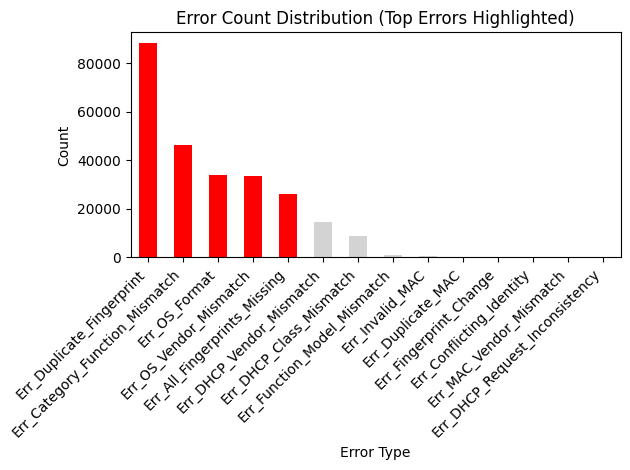

In [597]:
import matplotlib.pyplot as plt

error_counts = final_df[error_columns].sum().sort_values(ascending=False)

colors = ["red" if i < 5 else "lightgray" for i in range(len(error_counts))]

plt.figure()
error_counts.plot(kind="bar", color=colors)
plt.xticks(rotation=45, ha="right")
plt.title("Error Count Distribution (Top Errors Highlighted)")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Error Summary

In [598]:
error_summary = pd.DataFrame({
    "Error_Type": error_columns,
    "Count": [final_df[col].sum() for col in error_columns]
}).sort_values(by="Count", ascending=False)

In [599]:
error_summary["Percentage"] = (
    error_summary["Count"] / len(final_df) * 100
).round(2)

In [600]:
error_summary

,Error_Type,Count,Percentage
9,Err_Duplicate_Fingerprint,88384,99.85
2,Err_Category_Function_Mismatch,46480,52.51
7,Err_OS_Format,34172,38.61
0,Err_OS_Vendor_Mismatch,33728,38.11
10,Err_All_Fingerprints_Missing,26030,29.41
4,Err_DHCP_Vendor_Mismatch,14578,16.47
12,Err_DHCP_Class_Mismatch,8889,10.04
1,Err_Function_Model_Mismatch,1139,1.29
5,Err_Invalid_MAC,497,0.56
6,Err_Duplicate_MAC,14,0.02


### Data Quality Score

In [601]:
MAX_ERRORS = len(error_columns)

final_df["Data_Quality_Score"] = (
    (1 - final_df["Total_Error_Count"] / MAX_ERRORS) * 100
).round(1)

In [602]:
final_df["Data_Quality_Score"]

0        78.6
1        85.7
2        92.9
3        92.9
4        85.7
         ... 
88508    92.9
88509    85.7
88510    92.9
88511    78.6
88512    92.9
Name: Data_Quality_Score, Length: 88513, dtype: float64

In [603]:
final_df["Data_Quality_Score"].describe()

count    88513.000000
mean        79.502235
std          7.665884
min         42.900000
25%         71.400000
50%         78.600000
75%         85.700000
max        100.000000
Name: Data_Quality_Score, dtype: float64

In [604]:
final_df["DQ_Bucket"] = pd.cut(
    final_df["Data_Quality_Score"],
    bins=[0, 70, 85, 95, 100],
    labels=["Poor", "Moderate", "Good", "Excellent"]
)

In [605]:
final_df["DQ_Bucket"].value_counts()

DQ_Bucket
Moderate     48532
Good         38806
Poor          1156
Excellent       19
Name: count, dtype: int64

# Dashboard

In [606]:
from jupyter_dash import JupyterDash
from dash import dcc,html,Input,Output,Dash
import pandas as pd
import plotly.express as px

In [607]:
# Ensure error columns are boolean
error_columns = [c for c in final_df.columns if c.startswith("Err_")]
final_df[error_columns] = final_df[error_columns].fillna(False).astype(bool)

In [608]:
# app initialization
app = JupyterDash(__name__)

d:\Projects\network-asset-classification\.venv\Lib\site-packages\dash\dash.py:644: UserWarning: JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.
  warnings.warn(


In [609]:
# ================================
# COMMON CARD STYLE
# ================================
card_style = {
    "backgroundColor": "white",
    "padding": "10px",
    "margin": "10px",
    "borderRadius": "10px",
    "boxShadow": "2px 2px 10px rgba(0,0,0,0.1)"
}

In [610]:
# ================================
# LAYOUT
# ================================
app.layout = html.Div([

    html.H1("Asset Classification & Data Quality Dashboard",
            style={"textAlign": "center"}),

    # -------------------------------
    # FILTER SECTION (HORIZONTAL)
    # -------------------------------
    html.Div([

        html.Div([
            html.Label("Category", style={"fontWeight": "bold"}),
            dcc.Dropdown(
                options=[{"label": c, "value": c} for c in sorted(final_df["Category"].dropna().unique())],
                id="category_filter",
                multi=True,
                placeholder="Select Category"
            )
        ], style={"width": "30%", "margin": "5px"}),

        html.Div([
            html.Label("Risk Level", style={"fontWeight": "bold"}),
            dcc.Dropdown(
                options=[{"label": r, "value": r} for r in sorted(final_df["risk_level"].dropna().unique())],
                id="risk_filter",
                multi=True,
                placeholder="Select Risk Level"
            )
        ], style={"width": "30%", "margin": "5px"}),

        html.Div([
            html.Label("Model Type", style={"fontWeight": "bold"}),
            dcc.Dropdown(
                options=[{"label": m, "value": m} for m in sorted(final_df["Model_Type"].dropna().unique())],
                id="model_filter",
                multi=True,
                placeholder="Select Model Type"
            )
        ], style={"width": "30%", "margin": "5px"}),

    ], style={
        "display": "flex",
        "justifyContent": "space-between",
        "alignItems": "center",
        "backgroundColor": "white",
        "padding": "15px",
        "borderRadius": "10px",
        "boxShadow": "2px 2px 10px rgba(0,0,0,0.1)",
        "width": "85%",
        "margin": "auto"
    }),

    html.Hr(),  # ✅ FIXED (comma added above)

    # ================================
    # SECTION 1
    # ================================
    html.H2("Asset Overview"),

    html.Div([
        html.Div(dcc.Graph(id="category_dist"), style={**card_style, "width": "32%"}),
        html.Div(dcc.Graph(id="vendor_dist"), style={**card_style, "width": "32%"}),
        html.Div(dcc.Graph(id="os_dist"), style={**card_style, "width": "32%"}),
    ], style={"display": "flex"}),

    html.Hr(),

    # ================================
    # SECTION 2
    # ================================
    html.H2("Risk & Data Quality"),

    html.Div([
        html.Div(dcc.Graph(id="risk_dist"), style={**card_style, "width": "32%"}),
        html.Div(dcc.Graph(id="fp_integrity_dist"), style={**card_style, "width": "32%"}),
        html.Div(dcc.Graph(id="quality_score_dist"), style={**card_style, "width": "32%"}),
    ], style={"display": "flex"}),

    html.Hr(),

    # ================================
    # SECTION 3
    # ================================
    html.H2("Error Analysis"),

    html.Div([
        html.Div(dcc.Graph(id="error_counts"), style={**card_style, "width": "60%"}),

        html.Div([
            html.H4("Top 10 Assets with Most Errors"),
            html.Div(id="error_table")
        ], style={**card_style, "width": "40%"})
    ], style={"display": "flex"})

], style={
    "padding": "20px",
    "backgroundColor": "#f5f7fa"
})

In [611]:
# ================================
# FILTER FUNCTION
# ================================
def apply_filters(category, risk, model):
    dff = final_df.copy()

    if category:
        dff = dff[dff["Category"].isin(category)]

    if risk:
        dff = dff[dff["risk_level"].isin(risk)]

    if model:
        dff = dff[dff["Model_Type"].isin(model)]

    return dff

## Asset Overview

In [612]:
# ================================
# CATEGORY DISTRIBUTION
# ================================
@app.callback(
    Output("category_dist", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_category(category, risk, model):
    dff = apply_filters(category, risk, model)
    return px.pie(dff, names="Category", title="Asset Category Distribution")

In [613]:
# ================================
# VENDOR DISTRIBUTION
# ================================
@app.callback(
    Output("vendor_dist", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_vendor(category, risk, model):
    dff = apply_filters(category, risk, model)

    top_vendors = dff["vendor_normalized"].value_counts().nlargest(10).reset_index()
    top_vendors.columns = ["Vendor", "Count"]

    return px.bar(top_vendors, x="Vendor", y="Count", color="Vendor",title="Top 10 Vendors")

In [614]:
# ================================
# OS DISTRIBUTION
# ================================
@app.callback(
    Output("os_dist", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_os(category, risk, model):
    dff = apply_filters(category, risk, model)

    top_os = dff["OS_normalized"].value_counts().nlargest(10).reset_index()
    top_os.columns = ["OS", "Count"]

    return px.bar(top_os, x="OS", y="Count",color="OS", title="Top OS Distribution")

In [615]:
# ================================
# RISK DISTRIBUTION
# ================================
@app.callback(
    Output("risk_dist", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_risk(category, risk, model):
    dff = apply_filters(category, risk, model)
    return px.histogram(dff, x="risk_level", color="risk_level",title="Risk Level Distribution")

In [616]:
# ================================
# FINGERPRINT INTEGRITY
# ================================
@app.callback(
    Output("fp_integrity_dist", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_fp(category, risk, model):
    dff = apply_filters(category, risk, model)

    return px.histogram(
        dff,
        x="FP_Integrity_Score",
        color="FP_Integrity_Score",
        nbins=5,
        title="Fingerprint Integrity Score Distribution"
    )


In [617]:
# ================================
# DATA QUALITY SCORE
# ================================
@app.callback(
    Output("quality_score_dist", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_quality(category, risk, model):
    dff = apply_filters(category, risk, model)

    return px.histogram(
        dff,
        x="Data_Quality_Score",
        color="Data_Quality_Score",
        nbins=10,
        title="Data Quality Score Distribution"
    )

## Error  Section

In [618]:
# ================================
# ERROR DISTRIBUTION
# ================================
@app.callback(
    Output("error_counts", "figure"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_errors(category, risk, model):
    dff = apply_filters(category, risk, model)

    error_cols = [c for c in dff.columns if c.startswith("Err_")]

    error_summary = dff[error_cols].sum().sort_values(ascending=False).reset_index()
    error_summary.columns = ["Error Type", "Count"]

    return px.bar(error_summary, x="Error Type", y="Count", color="Error Type",title="Error Distribution")


In [619]:
# ================================
# TOP ERROR TABLE
# ================================
@app.callback(
    Output("error_table", "children"),
    Input("category_filter", "value"),
    Input("risk_filter", "value"),
    Input("model_filter", "value")
)
def update_table(category, risk, model):
    dff = apply_filters(category, risk, model)
    top = dff.sort_values("Total_Error_Count", ascending=False).head(10)

    return html.Table([
        html.Thead(html.Tr([
            html.Th("Asset ID"),
            html.Th("MAC Address"),
            html.Th("Errors")
        ], style={"backgroundColor": "#2c3e50", "color": "white"})),

        html.Tbody([
            html.Tr([
                html.Td(top.iloc[i]["Asset ID"]),
                html.Td(top.iloc[i]["MAC Address"]),
                html.Td(top.iloc[i]["Total_Error_Count"])
            ], style={"backgroundColor": "#ecf0f1"})
            for i in range(len(top))
        ])
    ],
    style={
        "width": "100%",
        "border": "1px solid black",
        "borderCollapse": "collapse",
        "textAlign": "center"
    })

In [620]:
if __name__== "__main__":
    app.run(mode="inline",bug=True)


In [ ]:
app.run(debug=True)

AssertionError: The setup method 'errorhandler' can no longer be called on the application. It has already handled its first request, any changes will not be applied consistently.
Make sure all imports, decorators, functions, etc. needed to set up the application are done before running it.

: 

: 